# convert split file

In [3]:
import json

# Define the path to the input and output JSON files
input_file = 'dataset/chain_set_splits.json'
output_file = 'dataset/cath42_split.json'

# Load the data from the input JSON file
with open(input_file, 'r') as infile:
    data = json.load(infile)

# Process the 'train', 'validation', and 'test' keys
new_data = {}
for key in ['train', 'validation', 'test']:
    if key in data:
        new_data[key] = [s.replace('.', '') for s in data[key]]

# Save the modified data to the output JSON file
with open(output_file, 'w') as outfile:
    json.dump(new_data, outfile, indent=4)

print(f"Processed data has been saved to {output_file}")


Processed data has been saved to dataset/cath42_split.json


# concat orig pdb files

In [8]:
import os
import json
from tqdm import tqdm

# Define paths
input_json_file = 'dataset/cath42_split.json'
pdb_folder = 'dataset/cath/v4_2_0/non-redundant-data-sets/dompdb'
output_folder = 'dataset/cath42_merged'

# Ensure the output directory exists
os.makedirs(output_folder, exist_ok=True)

# Load the JSON data
with open(input_json_file, 'r') as infile:
    data = json.load(infile)

# Function to concatenate and sort files
def concatenate_and_sort_files(base_name, files):
    concatenated_content = []
    for file_name in files:
        file_path = os.path.join(pdb_folder, file_name)
        if os.path.isfile(file_path):
            with open(file_path, 'r') as f:
                concatenated_content.extend(f.readlines())
    
    # Sort the concatenated content by the atom serial number (second column)
    concatenated_content.sort(key=lambda line: int(line.split()[1]))
    
    # Write the sorted content to the output file
    output_file_path = os.path.join(output_folder, base_name)
    with open(output_file_path, 'w') as f:
        f.writelines(concatenated_content)

# Process the keys 'train', 'validation', and 'test'
for key in ['train', 'validation', 'test']:
    if key in data:
        for value in tqdm(data[key]):
            base_name = value  # Use the value directly as the base name
            matching_files = [f for f in os.listdir(pdb_folder) if f.startswith(base_name)]
            concatenate_and_sort_files(base_name, matching_files)

print(f"Files have been concatenated and saved to {output_folder}")



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1120/1120 [00:42<00:00, 26.26it/s]

Files have been concatenated and saved to dataset/cath42_merged


# generate surface using original cath 4.2

In [ ]:
import os
from Bio.PDB import PDBParser, Structure, Model, Chain, Residue, Atom
from Bio.PDB.ResidueDepth import get_surface
import numpy as np
from tqdm import tqdm

# Define the path to the MSMS executable
msms_exec = '/gpfs/gibbs/pi/gerstein/xt86/surface/msms/msms.x86_64Linux2.2.6.1'

# Ensure MSMS is executable
os.chmod(msms_exec, 0o755)

# Define input and output directories
input_dir = 'dataset/cath/v4_2_0/non-redundant-data-sets/dompdb'
output_dir = 'surfaces'
os.makedirs(output_dir, exist_ok=True)

# Initialize PDB parser
parser = PDBParser(QUIET=True)

# Function to generate surface using MSMS and save as numpy array
def generate_surface(pdb_file, output_file):
    structure = parser.get_structure(os.path.basename(pdb_file), pdb_file)
    model = structure[0]
    try:
        surface = get_surface(model, MSMS=msms_exec)
        np.save(output_file, surface)
    except Exception as e:
        print(f"Failed to generate surface for {pdb_file}: {e}")

# Process each PDB file in the input directory
for filename in tqdm(os.listdir(input_dir)):
    pdb_file = os.path.join(input_dir, filename)
    output_file = os.path.join(output_dir, f"{filename}_surface.npy")
    
    # Generate surface
    generate_surface(pdb_file, output_file)

print("Surface generation and saving completed.")


# feature assignment

In [ ]:
import os
from Bio.PDB import PDBParser
import numpy as np
from tqdm import tqdm
from scipy.spatial import cKDTree

# Define input and output directories
input_dir = 'dataset/cath/v4_2_0/non-redundant-data-sets/dompdb'
surface_dir = 'surfaces'
output_dir = 'uncompressed_bio_feats'
os.makedirs(output_dir, exist_ok=True)

# Initialize PDB parser
parser = PDBParser(QUIET=True)

# Define the biochemical features dictionary
bio_feat_dict = {
    "hydrophobicity": {
        "I": 4.5, "V": 4.2, "L": 3.8, "F": 2.8, "C": 2.5, "M": 1.9, "A": 1.8,
        "W": -0.9, "G": -0.4, "T": -0.7, "S": -0.8, "Y": -1.3, "P": -1.6, "H": -3.2,
        "N": -3.5, "D": -3.5, "Q": -3.5, "E": -3.5, "K": -3.9, "R": -4.5
    },
    "charge": {
        "R": 1, "K": 1, "D": -1, "E": -1, "H": 0.1, "A": 0, "C": 0, "F": 0, "G": 0, "I": 0,
        "L": 0, "M": 0, "N": 0, "P": 0, "Q": 0, "S": 0, "T": 0, "V": 0, "W": 0, "Y": 0
    },
    "polarity": {
        "R": 1, "N": 1, "D": 1, "Q": 1, "E": 1, "H": 1, "K": 1, "S": 1, "T": 1, "Y": 1,
        "A": 0, "C": 0, "F": 0, "G": 0, "I": 0, "L": 0, "M": 0, "P": 0, "V": 0, "W": 0
    },
    "acceptor": {
        "D": 1, "E": 1, "N": 1, "Q": 1, "H": 1, "S": 1, "T": 1, "Y": 1,
        "A": 0, "C": 0, "F": 0, "G": 0, "I": 0, "K": 0, "L": 0, "M": 0, "P": 0, "R": 0, "V": 0, "W": 0
    },
    "donor": {
        "R": 1, "K": 1, "W": 1, "N": 1, "Q": 1, "H": 1, "S": 1, "T": 1, "Y": 1,
        "A": 0, "C": 0, "D": 0, "E": 0, "F": 0, "G": 0, "I": 0, "L": 0, "M": 0, "P": 0, "V": 0
    }
}

# Mapping from three-letter codes to one-letter codes
three_to_one = {
    "ALA": "A", "CYS": "C", "ASP": "D", "GLU": "E", "PHE": "F", "GLY": "G",
    "HIS": "H", "ILE": "I", "LYS": "K", "LEU": "L", "MET": "M", "ASN": "N",
    "PRO": "P", "GLN": "Q", "ARG": "R", "SER": "S", "THR": "T", "VAL": "V",
    "TRP": "W", "TYR": "Y"
}

# Function to get atom coordinates and residue types
def get_atom_coords_and_residues(structure):
    coords = []
    residues = []
    for model in structure:
        for chain in model:
            for residue in chain:
                for atom in residue:
                    coords.append(atom.coord)
                    residues.append(three_to_one.get(residue.get_resname(), ''))
    return np.array(coords), residues

# Process each PDB file in the input directory
for filename in tqdm(os.listdir(input_dir)):
    pdb_file = os.path.join(input_dir, filename)
    surface_file = os.path.join(surface_dir, f"{filename}_surface.npy")
    output_file = os.path.join(output_dir, f"{filename}_features.npy")
    
    if not os.path.isfile(surface_file):
        print(f"Surface file for {filename} not found, skipping.")
        continue

    # Load surface
    surface = np.load(surface_file, allow_pickle=True)
    
    # Parse PDB file
    structure = parser.get_structure(os.path.basename(pdb_file), pdb_file)
    atom_coords, residue_types = get_atom_coords_and_residues(structure)
    
    # Build k-D tree for atom coordinates
    kdtree = cKDTree(atom_coords)
    
    # Assign biochemical features to each vertex in the surface
    features = []
    for vertex in surface:
        dist, idx = kdtree.query(vertex)
        residue_type = residue_types[idx]
        residue_features = [bio_feat_dict[feat].get(residue_type, 0) for feat in bio_feat_dict]
        features.append(residue_features)
    
    # Convert features to a numpy array
    features_array = np.array(features)
    
    # Save features as a numpy array
    np.save(output_file, features_array)

print("Feature assignment completed.")


# surface smoothing

In [ ]:
import os
import numpy as np
import torch
from tqdm import tqdm

# Function to perform Gaussian kernel smoothing on all points using PyTorch
def gaussian_kernel_smoothing(coords, k=8, eta=None):
    # Convert numpy array to PyTorch tensor and move to GPU
    coords = torch.tensor(coords, dtype=torch.float32).cuda(1)
    
    # Compute the full pairwise distance matrix
    dists = torch.cdist(coords, coords, p=2)
    
    if eta is None:
        eta = torch.max(dists).item()
    
    # Find the indices of the k-nearest neighbors for each point
    # nearest_neighbors = torch.argsort(dists, dim=1)[:, 1:k+1]
    # Check the length and decide whether to use CPU for nearest neighbors
    if len(coords) > 40000:
        dists = dists.cpu()
        nearest_neighbors = torch.argsort(dists, dim=1)[:, 1:k+1]
        nearest_neighbors = nearest_neighbors.cuda(1)
        dists = dists.cuda(1)
    else:
        nearest_neighbors = torch.argsort(dists, dim=1)[:, 1:k+1]
    
    # Get the distances of the k-nearest neighbors
    nearest_dists = torch.gather(dists, 1, nearest_neighbors)
    
    # Compute weights using the Gaussian kernel
    weights = torch.exp(-nearest_dists**2 / eta)
    weights /= torch.sum(weights, dim=1, keepdim=True)
    
    # Compute the smoothed coordinates
    smoothed_coords = torch.sum(weights[:, :, None] * coords[nearest_neighbors], dim=1)
    
    return smoothed_coords.cpu().numpy()

# Directory containing the saved surfaces
input_dir = 'surfaces'
output_dir = 'smoothed_surfaces'
os.makedirs(output_dir, exist_ok=True)

# List all surface files
surface_files = [f for f in os.listdir(input_dir) if f.endswith('_surface.npy')]

for surface_file in tqdm(surface_files):
    # Load the surface
    surface_path = os.path.join(input_dir, surface_file)
    surface = np.load(surface_path)
    print(surface.shape)
    
    # Assuming the surface array contains vertex coordinates
    if len(surface.shape) != 2 or surface.shape[1] != 3:
        print(f"Unexpected surface shape for {surface_file}: {surface.shape}")
        continue
    
    # Perform Gaussian kernel smoothing
    smoothed_surface = gaussian_kernel_smoothing(surface)

    # Save the smoothed surface
    smoothed_surface_path = os.path.join(output_dir, surface_file)
    np.save(smoothed_surface_path, smoothed_surface)

print("Surface smoothing completed.")


# surface compression

In [ ]:
import os
import numpy as np
from tqdm import tqdm

class OctreeNode:
    def __init__(self, points, indices):
        self.points = points
        self.indices = indices
        self.children = []

def create_octree(points, indices, min_points_per_cube):
    """
    Create an octree for the given points.
    """
    def divide(points, indices):
        if len(points) <= min_points_per_cube:
            return OctreeNode(points, indices)
        centroid = np.mean(points, axis=0)
        partitions = [[] for _ in range(8)]
        partition_indices = [[] for _ in range(8)]
        for idx, point in enumerate(points):
            partition_index = 0
            if point[0] > centroid[0]:
                partition_index += 1
            if point[1] > centroid[1]:
                partition_index += 2
            if point[2] > centroid[2]:
                partition_index += 4
            partitions[partition_index].append(point)
            partition_indices[partition_index].append(indices[idx])
        node = OctreeNode(None, None)
        node.children = [divide(part, part_idx) for part, part_idx in zip(partitions, partition_indices)]
        return node

    return divide(points, indices)

def gather_points(node):
    """
    Gather points and indices from the octree.
    """
    if node.points is not None:
        return [(node.points, node.indices)]
    result = []
    for child in node.children:
        result.extend(gather_points(child))
    return result

def compress_surface(points, features, down_sample_ratio, min_points_per_cube):
    """
    Compress the surface and features using octree-based compression.
    """
    indices = np.arange(points.shape[0])
    octree = create_octree(points, indices, min_points_per_cube)
    compressed_points = []
    compressed_features = []
    for cube_points, cube_indices in gather_points(octree):
        local_density = len(cube_points)
        num_points = int(local_density * down_sample_ratio)
        if num_points > 0:
            sampled_indices = np.random.choice(local_density, num_points, replace=False)
            sampled_points = np.array(cube_points)[sampled_indices]
            sampled_features = features[cube_indices][sampled_indices]
            compressed_points.extend(sampled_points)
            compressed_features.extend(sampled_features)
    return np.array(compressed_points), np.array(compressed_features)

def main():
    input_folder = 'smoothed_surfaces'
    feature_folder = 'uncompressed_bio_feats'
    surface_output_folder = 'compressed_surfaces'
    feature_output_folder = 'compressed_bio_feats'
    min_points_per_cube = 32  # As per the paper's setting

    if not os.path.exists(surface_output_folder):
        os.makedirs(surface_output_folder)
    
    if not os.path.exists(feature_output_folder):
        os.makedirs(feature_output_folder)

    for file_name in tqdm(os.listdir(input_folder)):
        if file_name.endswith('_surface.npy'):
            base_name = file_name.replace('_surface.npy', '')
            surface_file_path = os.path.join(input_folder, file_name)
            feature_file_path = os.path.join(feature_folder, f'{base_name}_features.npy')
            
            points = np.load(surface_file_path)
            features = np.load(feature_file_path)
            
            original_point_count = len(points)
            
            if original_point_count > 5000:
                down_sample_ratio = 5000 / original_point_count
                compressed_points, compressed_features = compress_surface(points, features, down_sample_ratio, min_points_per_cube)
            else:
                compressed_points, compressed_features = points, features  # No down-sampling
            
            compressed_surface_path = os.path.join(surface_output_folder, f'{base_name}_surface.npy')
            compressed_feature_path = os.path.join(feature_output_folder, f'{base_name}_features.npy')
            
            np.save(compressed_surface_path, compressed_points)
            np.save(compressed_feature_path, compressed_features)
            # print(f'Processed and saved: {file_name}')

if __name__ == '__main__':
    main()


# seq processing

In [4]:
import os
import numpy as np
from Bio import PDB
from tqdm import tqdm

# Define the mapping from three-letter to one-letter amino acid codes
three_to_one = {
    "ALA": "A", "CYS": "C", "ASP": "D", "GLU": "E", "PHE": "F", "GLY": "G",
    "HIS": "H", "ILE": "I", "LYS": "K", "LEU": "L", "MET": "M", "ASN": "N",
    "PRO": "P", "GLN": "Q", "ARG": "R", "SER": "S", "THR": "T", "VAL": "V",
    "TRP": "W", "TYR": "Y"
}

# Define the mapping from one-letter amino acid codes to numerical values
one_to_num = {v: i for i, (k, v) in enumerate(three_to_one.items())}

def get_residue_sequence(file_path):
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure('structure', file_path)
    sequence = []

    for model in structure:
        for chain in model:
            for residue in chain:
                if PDB.is_aa(residue, standard=True):
                    res_name = residue.get_resname()
                    if res_name in three_to_one:
                        one_letter = three_to_one[res_name]
                        sequence.append(one_to_num[one_letter])
    
    return np.array(sequence)

# Define the folders
input_folder_path = "dataset/cath42_merged"
output_folder_path = "dataset/cath42_seqs"

# Create the output folder if it doesn't exist
os.makedirs(output_folder_path, exist_ok=True)

# Process each file in the input folder
for file_name in tqdm(os.listdir(input_folder_path)):
    file_path = os.path.join(input_folder_path, file_name)
    if os.path.isfile(file_path):
        residue_sequence = get_residue_sequence(file_path)
        output_file_name = file_name + "_seq.npy"
        output_file_path = os.path.join(output_folder_path, output_file_name)
        np.save(output_file_path, residue_sequence)
        # print(f"Saved: {output_file_path}")


  0%|                                                                                                                                                                                                                                                                | 2/19752 [00:00<27:48, 11.84it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19752/19752 [16:30<00:00, 19.93it/s]


# combine into 1 file

In [4]:
import os
import numpy as np
import pickle
from tqdm import tqdm

# Define the folder paths
surfaces_folder = 'compressed_smoothed_sorted_surfaces'
features_folder = 'compressed_sorted_bio_feats'
seqs_folder = 'dataset/cath42_seqs'
output_folder = 'dataset'
output_file = os.path.join(output_folder, 'combined_data.pkl')

# Create a dictionary to hold the combined data
combined_data = {}

# Get the list of files in each folder
surface_files = [f for f in os.listdir(surfaces_folder) if f.endswith('_surface.npy')]
feature_files = [f for f in os.listdir(features_folder) if f.endswith('_features.npy')]
seq_files = [f for f in os.listdir(seqs_folder) if f.endswith('_seq.npy')]

# Process each surface file
for surface_file in tqdm(surface_files):
    base = surface_file.replace('_surface.npy', '')
    surface_path = os.path.join(surfaces_folder, surface_file)
    feature_path = os.path.join(features_folder, f"{base}_features.npy")
    seq_path = os.path.join(seqs_folder, f"{base}_seq.npy")
    
    if os.path.exists(feature_path) and os.path.exists(seq_path):
        surface_data = np.load(surface_path)
        feature_data = np.load(feature_path)
        seq_data = np.load(seq_path)
        
        combined_data[base] = {
            'surface': surface_data,
            'features': feature_data,
            'seq': seq_data
        }

# Save the combined data to a file
with open(output_file, 'wb') as f:
    pickle.dump(combined_data, f)

output_file


  1%|█▍                                                                                                                                                                                                                                                           | 112/19750 [00:00<00:35, 559.08it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19750/19750 [09:53<00:00, 33.26it/s]


'dataset/combined_data.pkl'

# split

In [7]:
import json
import pickle

# Load the split information
with open('dataset/cath42_split.json', 'r') as f:
    split_data = json.load(f)

# Load the combined data
with open('dataset/combined_data.pkl', 'rb') as f:
    combined_data = pickle.load(f)

# Define the function to extract and save the split data
def save_split_data(split_key, split_bases, combined_data, output_folder='dataset'):
    split_dict = {base: combined_data[base] for base in split_bases if base in combined_data}
    output_file = os.path.join(output_folder, f'cath42_{split_key}.pkl')
    with open(output_file, 'wb') as f:
        pickle.dump(split_dict, f)
    return output_file

# Save each split
train_file = save_split_data('train', split_data['train'], combined_data)
validation_file = save_split_data('validation', split_data['validation'], combined_data)
test_file = save_split_data('test', split_data['test'], combined_data)

train_file, validation_file, test_file


('dataset/cath42_train.pkl',
 'dataset/cath42_validation.pkl',
 'dataset/cath42_test.pkl')

# check dataset number

In [2]:
import json
import pickle

# Load the split information
with open('dataset/cath42_split.json', 'r') as f:
    split_data = json.load(f)

# Load the combined data
with open('dataset/combined_data.pkl', 'rb') as f:
    combined_data = pickle.load(f)

In [7]:
def save_split_data(split_key, split_bases, combined_data, output_folder='dataset'):
    split_dict = {base: combined_data[base] for base in split_bases if base in combined_data}
    return split_dict

train_dict = save_split_data('train', split_data['train'], combined_data)
print(len(train_dict))
validation_dict = save_split_data('validation', split_data['validation'], combined_data)
print(len(validation_dict))
test_dict = save_split_data('test', split_data['test'], combined_data)
print(len(test_dict))

18022
608
1120


# filter pifold train set from 18024 to 18022

In [3]:
import pickle
import json

# Define the paths to the pickle files and JSON files
cath42_pc_test_path = 'dataset/cath42_pc_test.pkl'
cath42_pc_train_sorted_path = 'dataset/cath42_pc_train_sorted.pkl'
cath42_pc_validation_sorted_path = 'dataset/cath42_pc_validation_sorted.pkl'
chain_set_splits_path = 'dataset/chain_set_splits.json'
output_chain_set_splits_path = 'ProteinInvBench-lightning/data/cath4.2surfpropifold/chain_set_splits.json'

output_cath42_pc_test_path = 'ProteinInvBench-lightning/data/cath4.2surfpropifold/cath42_pc_test.pkl'
output_cath42_pc_train_sorted_path = 'ProteinInvBench-lightning/data/cath4.2surfpropifold/cath42_pc_train_sorted.pkl'
output_cath42_pc_validation_sorted_path = 'ProteinInvBench-lightning/data/cath4.2surfpropifold/cath42_pc_validation_sorted.pkl'

# Function to read pickle file
def read_pickle(file_path):
    with open(file_path, 'rb') as file:
        return pickle.load(file)

# Function to read JSON file
def read_json(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

# Function to write pickle file
def write_pickle(data, file_path):
    with open(file_path, 'wb') as file:
        pickle.dump(data, file)

# Read the pickle files
cath42_pc_test = read_pickle(cath42_pc_test_path)
cath42_pc_train_sorted = read_pickle(cath42_pc_train_sorted_path)
cath42_pc_validation_sorted = read_pickle(cath42_pc_validation_sorted_path)

# Read the JSON file
chain_set_splits = read_json(chain_set_splits_path)

# Create mappings from the split lists
def create_mapping(split_list):
    return {value.replace('.', ''): value for value in split_list}

train_map = create_mapping(chain_set_splits['train'])
validation_map = create_mapping(chain_set_splits['validation'])
test_map = create_mapping(chain_set_splits['test'])

# Function to rename keys in the dictionaries
def rename_keys(data_dict, mapping):
    return {mapping[key]: value for key, value in data_dict.items() if key in mapping}

# Rename the keys
cath42_pc_train_sorted_renamed = rename_keys(cath42_pc_train_sorted, train_map)
cath42_pc_validation_sorted_renamed = rename_keys(cath42_pc_validation_sorted, validation_map)
cath42_pc_test_renamed = rename_keys(cath42_pc_test, test_map)

# Filter chain_set_splits to contain the items in the respective dictionaries
filtered_train = [train_map[key] for key in cath42_pc_train_sorted.keys() if key in train_map]
filtered_validation = [validation_map[key] for key in cath42_pc_validation_sorted.keys() if key in validation_map]
filtered_test = [test_map[key] for key in cath42_pc_test.keys() if key in test_map]

# Create the new chain_set_splits dictionary
new_chain_set_splits = {
    'train': filtered_train,
    'validation': filtered_validation,
    'test': filtered_test
}

# Save the new chain_set_splits dictionary to a JSON file
with open(output_chain_set_splits_path, 'w') as file:
    json.dump(new_chain_set_splits, file, indent=2)

print(f"New chain_set_splits saved to {output_chain_set_splits_path}")

# Save the renamed pickle files
write_pickle(cath42_pc_test_renamed, output_cath42_pc_test_path)
write_pickle(cath42_pc_train_sorted_renamed, output_cath42_pc_train_sorted_path)
write_pickle(cath42_pc_validation_sorted_renamed, output_cath42_pc_validation_sorted_path)

print(f"Renamed pickle files saved to {output_chain_set_splits_path}")


New chain_set_splits saved to ProteinInvBench-lightning/data/cath4.2surfpropifold/chain_set_splits.json
Renamed pickle files saved to ProteinInvBench-lightning/data/cath4.2surfpropifold/chain_set_splits.json


In [1]:
import pickle
import json

# Define the paths to the pickle files and JSON files
cath42_pc_test_path = 'dataset/cath42_pc_test.pkl'
cath42_pc_train_sorted_path = 'dataset/cath42_pc_train_sorted.pkl'
cath42_pc_validation_sorted_path = 'dataset/cath42_pc_validation_sorted.pkl'
chain_set_splits_path = 'dataset/chain_set_splits.json'
output_chain_set_splits_path = 'ProteinInvBench-lightning/data/cath4.2surfpropifold/chain_set_splits.json'

output_cath42_pc_test_path = 'ProteinInvBench-lightning/data/cath4.2surfpropifold/cath42_pc_test.pkl'
output_cath42_pc_train_sorted_path = 'ProteinInvBench-lightning/data/cath4.2surfpropifold/cath42_pc_train_sorted.pkl'
output_cath42_pc_validation_sorted_path = 'ProteinInvBench-lightning/data/cath4.2surfpropifold/cath42_pc_validation_sorted.pkl'

# Function to read pickle file
def read_pickle(file_path):
    with open(file_path, 'rb') as file:
        return pickle.load(file)

# Read the pickle files
cath42_pc_test = read_pickle(output_cath42_pc_test_path)



In [6]:
list(cath42_pc_test.keys())[0]

'3fkf.A'

In [7]:
cath42_pc_test['3fkf.A']

{'surface': array([[32.65497  , -4.1823463, 21.217712 ],
        [33.441444 , -4.1061516, 15.883446 ],
        [33.098175 , -4.8152113, 21.538912 ],
        ...,
        [49.203514 , 11.382162 , 38.098457 ],
        [49.20714  , 11.350935 , 38.06326  ],
        [49.192993 , 11.421433 , 38.07891  ]], dtype=float32),
 'features': array([[ 1.8,  0. ,  0. ,  0. ,  0. ],
        [-3.5, -1. ,  1. ,  1. ,  0. ],
        [ 1.8,  0. ,  0. ,  0. ,  0. ],
        ...,
        [-3.5,  0. ,  1. ,  1. ,  1. ],
        [-3.5,  0. ,  1. ,  1. ,  1. ],
        [-3.5,  0. ,  1. ,  1. ,  1. ]]),
 'seq': array([17, 16, 17,  5,  8, 15,  0, 12, 19,  4, 15,  9, 12, 11,  3,  8,  5,
         3,  8,  9, 15, 14, 15,  0,  3, 14,  4, 14, 11, 14, 19,  9,  9,  9,
        11,  4, 18,  0, 15, 18,  1,  2, 12, 13, 12,  3,  0, 11,  0,  3,  9,
         8, 14,  9, 11,  8,  3, 19,  8,  8, 11,  8, 11,  4,  0,  9,  5,  7,
        15,  9,  2,  7,  2, 14,  3,  0, 18,  3, 16,  0,  7,  8,  8,  2, 16,
         9, 15, 18,  2, 13, 1

# sort dataset

In [8]:
import os
import pickle

# Define the input and output file paths
input_file = 'dataset/cath42_train.pkl'
output_file = 'dataset/cath42_train_sorted.pkl'

# Load the data from the pickle file
with open(input_file, 'rb') as f:
    data = pickle.load(f)

# Sort the data by vertex count in descending order
sorted_data = dict(sorted(data.items(), key=lambda item: item[1]['surface'].shape[0], reverse=True))

# Save the sorted data into a new pickle file
with open(output_file, 'wb') as f:
    pickle.dump(sorted_data, f)

print(f'Sorted data saved to {output_file}')


Sorted data saved to dataset/cath42_train_sorted.pkl


In [3]:
import os
import pickle

# Define the input and output file paths
input_file = 'dataset/cath42_validation.pkl'
output_file = 'dataset/cath42_validation_sorted.pkl'

# Load the data from the pickle file
with open(input_file, 'rb') as f:
    data = pickle.load(f)

# Sort the data by vertex count in descending order
sorted_data = dict(sorted(data.items(), key=lambda item: item[1]['surface'].shape[0], reverse=True))

# Save the sorted data into a new pickle file
with open(output_file, 'wb') as f:
    pickle.dump(sorted_data, f)

print(f'Sorted data saved to {output_file}')

Sorted data saved to dataset/cath42_validation_sorted.pkl


# create bipartite graph for surface and structure

In [3]:
import os
import pickle
import json
import numpy as np
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm

def add_ss_connection(data):
    max_float = np.finfo(np.float64).max
    surface_coords = data['surface']  # Use original surface coordinates
    ca_coords = data['CA']
    nbrs = NearestNeighbors(n_neighbors=8, algorithm='ball_tree').fit(np.nan_to_num(ca_coords, nan=max_float))
    distances, indices = nbrs.kneighbors(surface_coords)
    ss_connection = np.zeros((ca_coords.shape[0], surface_coords.shape[0]))
    for i, neighbors in enumerate(indices):
        ss_connection[neighbors, i] = 1
    data['ss_connection'] = ss_connection
    return data

def process_and_save(chain_set_path, splits_path, pickle_path, new_path, version, removeTS=False, remove=None, max_length=500):
    alphabet = 'ACDEFGHIKLMNPQRSTVWY'
    alphabet_set = set(alphabet)
    
    if not os.path.exists(new_path):
        os.makedirs(new_path)

    # Read chain_set.jsonl
    with open(chain_set_path + '/chain_set.jsonl') as f:
        lines = f.readlines()

    data_list = []
    for line in tqdm(lines):
        entry = json.loads(line)
        if removeTS and entry['name'] in remove:
            continue
        seq = entry['seq']

        for key, val in entry['coords'].items():
            entry['coords'][key] = np.asarray(val)

        bad_chars = set(seq).difference(alphabet_set)

        if len(bad_chars) == 0:
            if len(entry['seq']) <= max_length:
                chain_length = len(entry['seq'])
                chain_mask = np.ones(chain_length)
                data_list.append({
                    'title': entry['name'],
                    'seq': entry['seq'],
                    'CA': entry['coords']['CA'],
                    'C': entry['coords']['C'],
                    'O': entry['coords']['O'],
                    'N': entry['coords']['N'],
                    'chain_mask': chain_mask,
                    'chain_encoding': 1 * chain_mask
                })

    # Read dataset splits
    with open(splits_path + '/chain_set_splits.json') as f:
        dataset_splits = json.load(f)

    name2set = {}
    name2set.update({name: 'train' for name in dataset_splits['train']})
    name2set.update({name: 'valid' for name in dataset_splits['validation']})
    name2set.update({name: 'test' for name in dataset_splits['test']})

    # Load pickle files
    with open(pickle_path + '/cath42_pc_train_sorted.pkl', 'rb') as f:
        train_dict = pickle.load(f)
    with open(pickle_path + '/cath42_pc_validation_sorted.pkl', 'rb') as f:
        validation_dict = pickle.load(f)
    with open(pickle_path + '/cath42_pc_test.pkl', 'rb') as f:
        test_dict = pickle.load(f)

    # Combine data from JSONL and pickle files
    data_dict = {'train': train_dict, 'valid': validation_dict, 'test': test_dict}
    for data in data_list:
        title = data['title']
        if title in name2set:
            data_type = name2set[title]
            if title in data_dict[data_type]:
                data_dict[data_type][title]['CA'] = data['CA']
                data_dict[data_type][title] = add_ss_connection(data_dict[data_type][title])

    # Save new pickle files with the same names
    if 'train' in data_dict:
        with open(os.path.join(new_path, 'cath42_pc_train_sorted.pkl'), 'wb') as f:
            pickle.dump(data_dict['train'], f)
        print(f"Processed and saved cath42_pc_train_sorted.pkl to {new_path}")

    if 'valid' in data_dict:
        with open(os.path.join(new_path, 'cath42_pc_validation_sorted.pkl'), 'wb') as f:
            pickle.dump(data_dict['valid'], f)
        print(f"Processed and saved cath42_pc_validation_sorted.pkl to {new_path}")

    if 'test' in data_dict:
        with open(os.path.join(new_path, 'cath42_pc_test.pkl'), 'wb') as f:
            pickle.dump(data_dict['test'], f)
        print(f"Processed and saved cath42_pc_test.pkl to {new_path}")

    return data_dict

# Set paths
chain_set_path = "data/cath4.2surfpropifold"
splits_path = "data/cath4.2surfpropifold"
pickle_path = "data/cath4.2surfpropifold"
new_path = "data/cath4.2surfpropifold-connection"
version = 4.2  # Or 4.3, adjust as needed

# Process and save data
data_dict = process_and_save(chain_set_path, splits_path, pickle_path, new_path, version)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21668/21668 [00:14<00:00, 1490.95it/s]


Processed and saved cath42_pc_train_sorted.pkl to data/cath4.2surfpropifold-connection
Processed and saved cath42_pc_validation_sorted.pkl to data/cath4.2surfpropifold-connection
Processed and saved cath42_pc_test.pkl to data/cath4.2surfpropifold-connection


# test if surface and CA match

In [2]:
import numpy as np
import json
import pickle
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def normalize_coordinates(coords):
    # Placeholder normalization function, should be replaced with actual normalization logic
    return coords

class ProteinDataLoader:
    def __init__(self, path, removeTS, remove, max_length, version):
        self.path = path
        self.removeTS = removeTS
        self.remove = remove
        self.max_length = max_length
        self.version = version

    def cache_data(self):
        alphabet='ACDEFGHIKLMNPQRSTVWY'
        alphabet_set = set([a for a in alphabet])
        if not os.path.exists(self.path):
            raise FileNotFoundError("no such file: {} !!!".format(self.path))
        else:
            with open(self.path+'/chain_set.jsonl') as f:
                lines = f.readlines()
            data_list = []
            for line in tqdm(lines):
                entry = json.loads(line)
                if self.removeTS and entry['name'] in self.remove:
                    continue
                seq = entry['seq']

                for key, val in entry['coords'].items():
                    entry['coords'][key] = np.asarray(val)
                
                bad_chars = set([s for s in seq]).difference(alphabet_set)

                if len(bad_chars) == 0:
                    if len(entry['seq']) <= self.max_length: 
                        chain_length = len(entry['seq'])
                        chain_mask = np.ones(chain_length)
                        data_list.append({
                            'title':entry['name'],
                            'seq':entry['seq'],
                            'CA':entry['coords']['CA'],
                            'C':entry['coords']['C'],
                            'O':entry['coords']['O'],
                            'N':entry['coords']['N'],
                            'chain_mask': chain_mask,
                            'chain_encoding': 1*chain_mask
                        })
            
            if self.version in [4.2, 4.3]:
                with open(self.path+'/chain_set_splits.json') as f:
                    dataset_splits = json.load(f)
            
            name2set = {}
            name2set.update({name:'train' for name in dataset_splits['train']})
            name2set.update({name:'valid' for name in dataset_splits['validation']})
            name2set.update({name:'test' for name in dataset_splits['test']})

            # Load pickle files
            with open(self.path + '/cath42_pc_train_sorted.pkl', 'rb') as f:
                train_dict = pickle.load(f)
            with open(self.path + '/cath42_pc_validation_sorted.pkl', 'rb') as f:
                validation_dict = pickle.load(f)
            with open(self.path + '/cath42_pc_test.pkl', 'rb') as f:
                test_dict = pickle.load(f)

            # Combine data from JSONL and pickle files
            data_dict = {'train': [], 'valid': [], 'test': []}
            for data in data_list:
                title = data['title']
                if title in name2set:
                    data_type = name2set[title]
                    if data_type == 'train' and title in train_dict:
                        data['surface'] = normalize_coordinates(train_dict[title]['surface'])
                        data['features'] = train_dict[title]['features'][:, :2]
                        data['pc'] = train_dict[title]['pc']
                        data_dict['train'].append(data)
                    elif data_type == 'valid' and title in validation_dict:
                        data['surface'] = normalize_coordinates(validation_dict[title]['surface'])
                        data['features'] = validation_dict[title]['features'][:, :2]
                        data['pc'] = validation_dict[title]['pc']
                        data_dict['valid'].append(data)
                    elif data_type == 'test' and title in test_dict:
                        data['surface'] = normalize_coordinates(test_dict[title]['surface'])
                        data['features'] = test_dict[title]['features'][:, :2]
                        data['pc'] = test_dict[title]['pc']
                        data['category'] = 'Unknown'
                        data['score'] = 100.0
                        data_dict['test'].append(data)

            return data_dict

# Initialize the loader
loader = ProteinDataLoader(path='ProteinInvBench-lightning/data/cath4.2surfpropifold', removeTS=False, remove=[], max_length=1000, version=4.2)

# Load the data
data_dict = loader.cache_data()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3957972341.py, line 122)

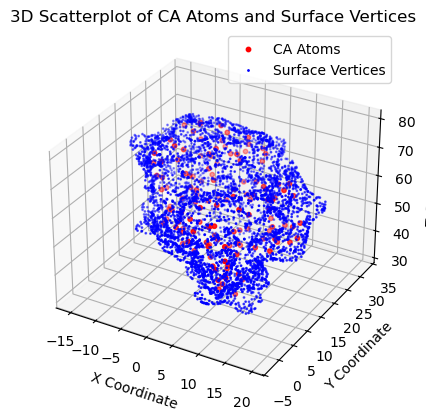

In [8]:
# Extract the first protein's data (assuming it's from the train set)
first_protein = data_dict['train'][1]

# Get CA coordinates
ca_coords = first_protein['CA']

# Get surface vertices
surface_coords = data_dict['train'][1]['surface']

# Plotting
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot CA atoms
ax.scatter(ca_coords[:, 0], ca_coords[:, 1], ca_coords[:, 2], c='r', marker='o', s=10, label='CA Atoms')

# Plot surface vertices
ax.scatter(surface_coords[:, 0], surface_coords[:, 1], surface_coords[:, 2], c='b', marker='o', s=1, label='Surface Vertices')

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')
ax.legend()
ax.set_title('3D Scatterplot of CA Atoms and Surface Vertices')

plt.show()

In [14]:
data_dict['train'][0]['N'].shape

(330, 3)

In [16]:
len(data_dict['train'][0]['seq'])

330

# pca

In [1]:
import os
import pickle
import numpy as np
import torch
from tqdm import tqdm

# Define the input and output file paths
input_file = 'dataset/cath42_train_sorted.pkl'
output_file = 'dataset/cath42_pc_train_sorted.pkl'

# Load the data from the pickle file
with open(input_file, 'rb') as f:
    data = pickle.load(f)

# Function to compute PCA
def compute_pca(vertices, K=3, device='cuda:3'):
    vertices = torch.tensor(vertices, dtype=torch.float32).to(device)
    vertices_mean = vertices.mean(dim=0, keepdim=True)
    vertices_centered = vertices - vertices_mean
    U, S, V = torch.pca_lowrank(vertices_centered)
    principal_components = V[:, :K]
    return principal_components.cpu().numpy()

# Process each item and add the principal components
for base, item in tqdm(data.items()):
    surface = item['surface']
    pc = compute_pca(surface)
    item['pc'] = pc

# Save the updated data into a new pickle file
with open(output_file, 'wb') as f:
    pickle.dump(data, f)

print(f'Updated data with principal components saved to {output_file}')


100%|███████████████████████████████████████████████████████████████| 18022/18022 [00:18<00:00, 972.64it/s]


Updated data with principal components saved to dataset/cath42_pc_train_sorted.pkl


In [4]:
import os
import pickle
import numpy as np
import torch
from tqdm import tqdm

# Define the input and output file paths
input_file = 'dataset/cath42_validation_sorted.pkl'
output_file = 'dataset/cath42_pc_validation_sorted.pkl'

# Load the data from the pickle file
with open(input_file, 'rb') as f:
    data = pickle.load(f)

# Function to compute PCA
def compute_pca(vertices, K=3, device='cuda:3'):
    vertices = torch.tensor(vertices, dtype=torch.float32).to(device)
    vertices_mean = vertices.mean(dim=0, keepdim=True)
    vertices_centered = vertices - vertices_mean
    U, S, V = torch.pca_lowrank(vertices_centered)
    principal_components = V[:, :K]
    return principal_components.cpu().numpy()

# Process each item and add the principal components
for base, item in tqdm(data.items()):
    surface = item['surface']
    pc = compute_pca(surface)
    item['pc'] = pc

# Save the updated data into a new pickle file
with open(output_file, 'wb') as f:
    pickle.dump(data, f)

print(f'Updated data with principal components saved to {output_file}')


100%|███████████████████████████████████████████████████████████████████| 608/608 [00:01<00:00, 499.05it/s]


Updated data with principal components saved to dataset/cath42_pc_validation_sorted.pkl


In [19]:
import os
import pickle
import numpy as np
import torch
from tqdm import tqdm

# Define the input and output file paths
input_file = 'dataset/cath42_test.pkl'
output_file = 'dataset/cath42_pc_test.pkl'

# Load the data from the pickle file
with open(input_file, 'rb') as f:
    data = pickle.load(f)

# Function to compute PCA
def compute_pca(vertices, K=3, device='cuda:3'):
    vertices = torch.tensor(vertices, dtype=torch.float32).to(device)
    vertices_mean = vertices.mean(dim=0, keepdim=True)
    vertices_centered = vertices - vertices_mean
    U, S, V = torch.pca_lowrank(vertices_centered)
    principal_components = V[:, :K]
    return principal_components.cpu().numpy()

# Process each item and add the principal components
for base, item in tqdm(data.items()):
    surface = item['surface']
    pc = compute_pca(surface)
    item['pc'] = pc

# Save the updated data into a new pickle file
with open(output_file, 'wb') as f:
    pickle.dump(data, f)

print(f'Updated data with principal components saved to {output_file}')


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1120/1120 [00:02<00:00, 396.72it/s]


Updated data with principal components saved to dataset/cath42_pc_test.pkl


# inside space biochem feats

In [1]:
import os
import numpy as np
import pickle
import warnings
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import is_aa
from Bio.SeqUtils import seq1
from scipy.spatial import Delaunay, cKDTree
from tqdm import tqdm
from Bio.PDB.PDBExceptions import PDBConstructionWarning

# Suppress PDBConstructionWarning
warnings.simplefilter('ignore', PDBConstructionWarning)

# Define hydrophobicity scale (Kyte-Doolittle)
hydrophobicity_scale = {
    'A': 1.8, 'C': 2.5, 'D': -3.5, 'E': -3.5, 'F': 2.8,
    'G': -0.4, 'H': -3.2, 'I': 4.5, 'K': -3.9, 'L': 3.8,
    'M': 1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5, 'R': -4.5,
    'S': -0.8, 'T': -0.7, 'V': 4.2, 'W': -0.9, 'Y': -1.3
}

# Define charge scale
charge_scale = {
    'D': -1, 'E': -1, 'K': 1, 'R': 1, 'H': 0.1  # Histidine is partially charged
}

# Define polarity, acceptor, and donor features as shown in the image
polarity_scale = {'R': 1, 'N': 1, 'D': 1, 'Q': 1, 'E': 1, 'H': 1, 'K': 1, 'S': 1, 'T': 1, 'Y': 1}
acceptor_scale = {'D': 1, 'E': 1, 'N': 1, 'Q': 1, 'H': 1, 'S': 1, 'T': 1, 'Y': 1}
donor_scale = {'R': 1, 'K': 1, 'W': 1, 'N': 1, 'Q': 1, 'H': 1, 'S': 1, 'T': 1, 'Y': 1}

# Define file paths
input_files = [
    'ProteinInvBench-lightning/data/cath4.2surfpropifold/cath42_pc_test.pkl',
    'ProteinInvBench-lightning/data/cath4.2surfpropifold/cath42_pc_train_sorted.pkl',
    'ProteinInvBench-lightning/data/cath4.2surfpropifold/cath42_pc_validation_sorted.pkl'
]
output_dir = 'ProteinInvBench-lightning/data/cath4.2surfpropifold-dense'
pdb_dir = 'dataset/cath42_merged'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Function to get biochemical features from a residue
def get_biochem_features(residue):
    res_3letter = residue.get_resname()  # Get the three-letter code
    res_1letter = seq1(res_3letter)  # Convert to one-letter code
    hydrophobicity = hydrophobicity_scale.get(res_1letter, 0)
    charge = charge_scale.get(res_1letter, 0)
    polarity = polarity_scale.get(res_1letter, 0)
    acceptor = acceptor_scale.get(res_1letter, 0)
    donor = donor_scale.get(res_1letter, 0)
    return np.array([hydrophobicity, charge, polarity, acceptor, donor])

def sample_if_needed(data_dict, max_length=5000):
    for key, value in data_dict.items():
        surface = value['surface']
        features = value['features']
        
        if len(surface) > max_length:
            indices = np.random.choice(len(surface), max_length, replace=False)
            value['surface'] = surface[indices]
            value['features'] = features[indices]
    
    return data_dict

# Process each file
for file in input_files:
    with open(file, 'rb') as f:
        data = pickle.load(f)

    # Iterate through each protein in the dataset
    for key, value in tqdm(data.items(), desc=f"Processing {os.path.basename(file)}"):
        pdb_key = key.replace('.', '')
        pdb_file = os.path.join(pdb_dir, pdb_key)

        # Parse the PDB file
        parser = PDBParser()
        structure = parser.get_structure("protein", pdb_file)
        
        # Extract residue info and calculate biochemical features
        coords = []
        features = []

        for model in structure:
            for chain in model:
                for residue in chain:
                    if is_aa(residue) and 'CA' in residue:
                        res_coord = residue['CA'].get_coord()  # Get alpha carbon coordinates
                        res_features = get_biochem_features(residue)

                        coords.append(res_coord)
                        features.append(res_features)

        coords = np.array(coords)
        features = np.array(features)

        # Build a KDTree for fast nearest-neighbor search
        kdtree = cKDTree(coords)

        # Surface points and features
        surface_points = value['surface']
        surface_features = value['features']

        # Generate random points inside the surface
        min_coords = surface_points.min(axis=0)
        max_coords = surface_points.max(axis=0)
        num_samples = 5000
        random_points = np.random.uniform(min_coords, max_coords, (num_samples, 3))

        tri = Delaunay(surface_points)

        def is_inside(point, tri):
            return tri.find_simplex(point) >= 0

        inside_points = np.array([p for p in random_points if is_inside(p, tri)])

        # Assign biochemical features to random points based on nearest residue
        _, idx = kdtree.query(inside_points)
        inside_features = features[idx]

        # Concatenate surface and inside points and features
        new_surface = np.concatenate([surface_points, inside_points], axis=0)
        new_features = np.concatenate([surface_features, inside_features], axis=0)

        # Update the original dict with new surface and features
        value['surface'] = new_surface
        value['features'] = new_features

    data = sample_if_needed(data)
    # Save the updated data structure back to a new file
    output_file = os.path.join(output_dir, os.path.basename(file))
    with open(output_file, 'wb') as f:
        pickle.dump(data, f)

print("Processing complete.")


Processing cath42_pc_validation_sorted.pkl: 100%|██████████| 608/608 [02:36<00:00,  3.88it/s]


Processing complete.


# recovery rate

## last epoch before breaking

In [1]:
import torch
import torch.nn as nn
import pickle
from SurfPro256 import SurfProModel
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
from tqdm import tqdm

# Initialize the model
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
model = SurfProModel().to(device)
model = nn.DataParallel(model, device_ids=[3]) 
# Load the model state
model_path = 'model07171400/surfpro_epoch6.pth'
model.load_state_dict(torch.load(model_path))

# Load the test dataset
with open('dataset/cath42_pc_test.pkl', 'rb') as f:
    test_data = pickle.load(f)

# Define the mapping from three-letter to one-letter amino acid codes
three_to_one = {
    "ALA": "A", "CYS": "C", "ASP": "D", "GLU": "E", "PHE": "F", "GLY": "G",
    "HIS": "H", "ILE": "I", "LYS": "K", "LEU": "L", "MET": "M", "ASN": "N",
    "PRO": "P", "GLN": "Q", "ARG": "R", "SER": "S", "THR": "T", "VAL": "V",
    "TRP": "W", "TYR": "Y"
}

# Define the mapping from one-letter amino acid codes to numerical values
one_to_num = {v: i for i, (k, v) in enumerate(three_to_one.items())}
num_to_one = {v: k for k, v in one_to_num.items()}

# Process each test sample
results = []
recovery_rates = []

for key, value in tqdm(test_data.items()):
    surface = torch.tensor(value['surface'], dtype=torch.float32).unsqueeze(0).to(device)
    features = torch.tensor(value['features'][:, :2], dtype=torch.float32).unsqueeze(0).to(device)
    pc = torch.tensor(value['pc'], dtype=torch.float32).unsqueeze(0).to(device)
    ground_truth_seq = value['seq']

    # Model prediction
    model.eval()
    with torch.no_grad():
        output = model(surface, features, pc)
    
    # Convert model output to predicted sequence
    predicted_indices = output.squeeze(0)[: -1].cpu().numpy()
    predicted_seq = ''.join([num_to_one[idx] for idx in predicted_indices])

    # Convert ground truth numerical sequence to string
    ground_truth_seq_str = ''.join([num_to_one[idx] for idx in ground_truth_seq])

    # Align predicted sequence with ground truth sequence
    alignments = pairwise2.align.globalxx(predicted_seq, ground_truth_seq_str)
    
    # Calculate recovery rate
    recovery_rate = alignments[0].score / len(ground_truth_seq_str)
    results.append((key, predicted_seq, ground_truth_seq_str, recovery_rate))
    recovery_rates.append(recovery_rate)

# Summarize results
average_recovery_rate = sum([result[3] for result in results]) / len(results)
print(f"Average Recovery Rate: {average_recovery_rate}")


/gpfs/gibbs/pi/gerstein/xt86/.conda/envs/msms/lib/python3.8/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1120/1120 [2:52:50<00:00,  9.26s/it]

Average Recovery Rate: 0.40029578227796253


## random model

In [13]:
import torch
import torch.nn as nn
import pickle
from SurfPro256 import SurfProModel
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
from tqdm import tqdm

# Initialize the model
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
model = SurfProModel().to(device)
model = nn.DataParallel(model, device_ids=[2, 3]) 

# Load the test dataset
with open('dataset/cath42_pc_test.pkl', 'rb') as f:
    test_data = pickle.load(f)

# Define the mapping from three-letter to one-letter amino acid codes
three_to_one = {
    "ALA": "A", "CYS": "C", "ASP": "D", "GLU": "E", "PHE": "F", "GLY": "G",
    "HIS": "H", "ILE": "I", "LYS": "K", "LEU": "L", "MET": "M", "ASN": "N",
    "PRO": "P", "GLN": "Q", "ARG": "R", "SER": "S", "THR": "T", "VAL": "V",
    "TRP": "W", "TYR": "Y"
}

# Define the mapping from one-letter amino acid codes to numerical values
one_to_num = {v: i for i, (k, v) in enumerate(three_to_one.items())}
num_to_one = {v: k for k, v in one_to_num.items()}

# Process each test sample
results = []
recovery_rates = []

for key, value in tqdm(test_data.items()):
    surface = torch.tensor(value['surface'], dtype=torch.float32).unsqueeze(0).to(device)
    features = torch.tensor(value['features'][:, :2], dtype=torch.float32).unsqueeze(0).to(device)
    pc = torch.tensor(value['pc'], dtype=torch.float32).unsqueeze(0).to(device)
    ground_truth_seq = value['seq']

    # Model prediction
    model.eval()
    with torch.no_grad():
        output = model(surface, features, pc)
    
    # Convert model output to predicted sequence
    predicted_indices = output.squeeze(0).cpu().numpy()
    predicted_indices = predicted_indices[(predicted_indices >= 0) & (predicted_indices <= 19)]
    predicted_seq = ''.join([num_to_one[idx] for idx in predicted_indices])

    # Convert ground truth numerical sequence to string
    ground_truth_seq_str = ''.join([num_to_one[idx] for idx in ground_truth_seq])

    # Align predicted sequence with ground truth sequence
    alignments = pairwise2.align.globalxx(predicted_seq, ground_truth_seq_str)
    
    # Calculate recovery rate
    recovery_rate = alignments[0].score / len(ground_truth_seq_str)
    results.append((key, predicted_seq, ground_truth_seq_str, recovery_rate))
    recovery_rates.append(recovery_rate)

# Summarize results
average_recovery_rate = sum([result[3] for result in results]) / len(results)
print(f"Average Recovery Rate: {average_recovery_rate}")


  0%|                                                                                                                                                                                                                                                                                  | 0/1120 [00:00<?, ?it/s]/gpfs/gibbs/pi/gerstein/xt86/.conda/envs/msms/lib/python3.8/site-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1120/1120 [02:47<00:00,  6.68it/s]

Average Recovery Rate: 0.01471514862921685


## after the 1st epoch (2 a100, 5e-5)

In [1]:
import torch
import torch.nn as nn
import pickle
from SurfPro256 import SurfProModel
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
from tqdm import tqdm

# Initialize the model
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
model = SurfProModel().to(device)
model = nn.DataParallel(model, device_ids=[2, 3]) 
# Load the model state
model_path = 'model07180000/surfpro_epoch1.pth'
model.load_state_dict(torch.load(model_path))

# Load the test dataset
with open('dataset/cath42_pc_test.pkl', 'rb') as f:
    test_data = pickle.load(f)

# Define the mapping from three-letter to one-letter amino acid codes
three_to_one = {
    "ALA": "A", "CYS": "C", "ASP": "D", "GLU": "E", "PHE": "F", "GLY": "G",
    "HIS": "H", "ILE": "I", "LYS": "K", "LEU": "L", "MET": "M", "ASN": "N",
    "PRO": "P", "GLN": "Q", "ARG": "R", "SER": "S", "THR": "T", "VAL": "V",
    "TRP": "W", "TYR": "Y"
}

# Define the mapping from one-letter amino acid codes to numerical values
one_to_num = {v: i for i, (k, v) in enumerate(three_to_one.items())}
num_to_one = {v: k for k, v in one_to_num.items()}

# Process each test sample
results = []
recovery_rates = []

for key, value in tqdm(test_data.items()):
    surface = torch.tensor(value['surface'], dtype=torch.float32).unsqueeze(0).to(device)
    features = torch.tensor(value['features'][:, :2], dtype=torch.float32).unsqueeze(0).to(device)
    pc = torch.tensor(value['pc'], dtype=torch.float32).unsqueeze(0).to(device)
    ground_truth_seq = value['seq']

    # Model prediction
    model.eval()
    with torch.no_grad():
        output = model(surface, features, pc)
    
    # Convert model output to predicted sequence
    predicted_indices = output.squeeze(0).cpu().numpy()
    predicted_indices = predicted_indices[(predicted_indices >= 0) & (predicted_indices <= 19)]
    predicted_seq = ''.join([num_to_one[idx] for idx in predicted_indices])

    # Convert ground truth numerical sequence to string
    ground_truth_seq_str = ''.join([num_to_one[idx] for idx in ground_truth_seq])

    # Align predicted sequence with ground truth sequence
    alignments = pairwise2.align.globalxx(predicted_seq, ground_truth_seq_str)
    
    # Calculate recovery rate
    recovery_rate = alignments[0].score / len(ground_truth_seq_str)
    results.append((key, predicted_seq, ground_truth_seq_str, recovery_rate))
    recovery_rates.append(recovery_rate)

# Summarize results
average_recovery_rate = sum([result[3] for result in results]) / len(results)
print(f"Average Recovery Rate: {average_recovery_rate}")


/gpfs/gibbs/pi/gerstein/xt86/.conda/envs/msms/lib/python3.8/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(
  0%|                                                                                                                                                                                                                                                                                  | 0/1120 [00:00<?, ?it/s]/gpfs/gibbs/pi/gerstein/xt86/.conda/envs/msms/lib/python3.8/site-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
 86%|█████████████████████████████████████████████████████

In [2]:
average_recovery_rate

0.19132973381614046

## 30th epoch (2 a100, 5e-5)

In [1]:
import torch
import torch.nn as nn
import pickle
from SurfPro256 import SurfProModel
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
from tqdm import tqdm

# Initialize the model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SurfProModel().to(device)
model = nn.DataParallel(model, device_ids=[0, 1]) 
# Load the model state
model_path = 'model07180000/surfpro_epoch30.pth'
model.load_state_dict(torch.load(model_path))

# Load the test dataset
with open('dataset/cath42_pc_test.pkl', 'rb') as f:
    test_data = pickle.load(f)

# Define the mapping from three-letter to one-letter amino acid codes
three_to_one = {
    "ALA": "A", "CYS": "C", "ASP": "D", "GLU": "E", "PHE": "F", "GLY": "G",
    "HIS": "H", "ILE": "I", "LYS": "K", "LEU": "L", "MET": "M", "ASN": "N",
    "PRO": "P", "GLN": "Q", "ARG": "R", "SER": "S", "THR": "T", "VAL": "V",
    "TRP": "W", "TYR": "Y"
}

# Define the mapping from one-letter amino acid codes to numerical values
one_to_num = {v: i for i, (k, v) in enumerate(three_to_one.items())}
num_to_one = {v: k for k, v in one_to_num.items()}

# Process each test sample
results = []
recovery_rates = []

for key, value in tqdm(test_data.items()):
    surface = torch.tensor(value['surface'], dtype=torch.float32).unsqueeze(0).to(device)
    features = torch.tensor(value['features'][:, :2], dtype=torch.float32).unsqueeze(0).to(device)
    pc = torch.tensor(value['pc'], dtype=torch.float32).unsqueeze(0).to(device)
    ground_truth_seq = value['seq']

    # Model prediction
    model.eval()
    with torch.no_grad():
        output = model(surface, features, pc)
    
    # Convert model output to predicted sequence
    predicted_indices = output.squeeze(0).cpu().numpy()
    predicted_indices = predicted_indices[(predicted_indices >= 0) & (predicted_indices <= 19)]
    predicted_seq = ''.join([num_to_one[idx] for idx in predicted_indices])

    # Convert ground truth numerical sequence to string
    ground_truth_seq_str = ''.join([num_to_one[idx] for idx in ground_truth_seq])

    # Align predicted sequence with ground truth sequence
    alignments = pairwise2.align.globalxx(predicted_seq, ground_truth_seq_str)
    
    # Calculate recovery rate
    recovery_rate = alignments[0].score / len(ground_truth_seq_str)
    results.append((key, predicted_seq, ground_truth_seq_str, recovery_rate))
    recovery_rates.append(recovery_rate)

# Summarize results
average_recovery_rate = sum([result[3] for result in results]) / len(results)
print(f"Average Recovery Rate: {average_recovery_rate}")


/gpfs/gibbs/pi/gerstein/xt86/.conda/envs/msms/lib/python3.8/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(
  0%|                                                                                                                                                                                                                                                                         | 0/1120 [00:00<?, ?it/s]/gpfs/gibbs/pi/gerstein/xt86/.conda/envs/msms/lib/python3.8/site-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
100%|██████████████████████████████████████████████████████████████

Average Recovery Rate: 0.3794670352537254


## (30+5)th epoch (2 a100, 2e-5)

In [1]:
import torch
import torch.nn as nn
import pickle
from SurfPro256 import SurfProModel
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
from tqdm import tqdm

# Initialize the model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SurfProModel().to(device)
model = nn.DataParallel(model, device_ids=[0, 1]) 
# Load the model state
model_path = 'model07182000/surfpro_epoch5.pth'
model.load_state_dict(torch.load(model_path))

# Load the test dataset
with open('dataset/cath42_pc_test.pkl', 'rb') as f:
    test_data = pickle.load(f)

# Define the mapping from three-letter to one-letter amino acid codes
three_to_one = {
    "ALA": "A", "CYS": "C", "ASP": "D", "GLU": "E", "PHE": "F", "GLY": "G",
    "HIS": "H", "ILE": "I", "LYS": "K", "LEU": "L", "MET": "M", "ASN": "N",
    "PRO": "P", "GLN": "Q", "ARG": "R", "SER": "S", "THR": "T", "VAL": "V",
    "TRP": "W", "TYR": "Y"
}

# Define the mapping from one-letter amino acid codes to numerical values
one_to_num = {v: i for i, (k, v) in enumerate(three_to_one.items())}
num_to_one = {v: k for k, v in one_to_num.items()}

# Process each test sample
results = []
recovery_rates = []

for key, value in tqdm(test_data.items()):
    surface = torch.tensor(value['surface'], dtype=torch.float32).unsqueeze(0).to(device)
    features = torch.tensor(value['features'][:, :2], dtype=torch.float32).unsqueeze(0).to(device)
    pc = torch.tensor(value['pc'], dtype=torch.float32).unsqueeze(0).to(device)
    ground_truth_seq = value['seq']

    # Model prediction
    model.eval()
    with torch.no_grad():
        output = model(surface, features, pc)
    
    # Convert model output to predicted sequence
    predicted_indices = output.squeeze(0).cpu().numpy()
    predicted_indices = predicted_indices[(predicted_indices >= 0) & (predicted_indices <= 19)]
    predicted_seq = ''.join([num_to_one[idx] for idx in predicted_indices])

    # Convert ground truth numerical sequence to string
    ground_truth_seq_str = ''.join([num_to_one[idx] for idx in ground_truth_seq])

    # Align predicted sequence with ground truth sequence
    alignments = pairwise2.align.globalxx(predicted_seq, ground_truth_seq_str)
    
    # Calculate recovery rate
    recovery_rate = alignments[0].score / len(ground_truth_seq_str)
    results.append((key, predicted_seq, ground_truth_seq_str, recovery_rate))
    recovery_rates.append(recovery_rate)

# Summarize results
average_recovery_rate = sum([result[3] for result in results]) / len(results)
print(f"Average Recovery Rate: {average_recovery_rate}")


/gpfs/gibbs/pi/gerstein/xt86/.conda/envs/msms/lib/python3.8/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(
  0%|                                                                                                                                                                                                                                                                         | 0/1120 [00:00<?, ?it/s]/gpfs/gibbs/pi/gerstein/xt86/.conda/envs/msms/lib/python3.8/site-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
100%|██████████████████████████████████████████████████████████████

Average Recovery Rate: 0.37508382003916024


## (30+7+4)th epoch (2 a100, 5e-4 grac clipping)

In [3]:
import torch
import torch.nn as nn
import pickle
from SurfPro256 import SurfProModel
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
from tqdm import tqdm

# Initialize the model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SurfProModel().to(device)
model = nn.DataParallel(model, device_ids=[0, 1]) 
# Load the model state
model_path = 'model07191000/surfpro_epoch4.pth'
model.load_state_dict(torch.load(model_path))

# Load the test dataset
with open('dataset/cath42_pc_test.pkl', 'rb') as f:
    test_data = pickle.load(f)

# Define the mapping from three-letter to one-letter amino acid codes
three_to_one = {
    "ALA": "A", "CYS": "C", "ASP": "D", "GLU": "E", "PHE": "F", "GLY": "G",
    "HIS": "H", "ILE": "I", "LYS": "K", "LEU": "L", "MET": "M", "ASN": "N",
    "PRO": "P", "GLN": "Q", "ARG": "R", "SER": "S", "THR": "T", "VAL": "V",
    "TRP": "W", "TYR": "Y"
}

# Define the mapping from one-letter amino acid codes to numerical values
one_to_num = {v: i for i, (k, v) in enumerate(three_to_one.items())}
num_to_one = {v: k for k, v in one_to_num.items()}

# Process each test sample
results = []
recovery_rates = []

for key, value in tqdm(test_data.items()):
    surface = torch.tensor(value['surface'], dtype=torch.float32).unsqueeze(0).to(device)
    features = torch.tensor(value['features'][:, :2], dtype=torch.float32).unsqueeze(0).to(device)
    pc = torch.tensor(value['pc'], dtype=torch.float32).unsqueeze(0).to(device)
    ground_truth_seq = value['seq']

    # Model prediction
    model.eval()
    with torch.no_grad():
        output = model(surface, features, pc)
    
    # Convert model output to predicted sequence
    predicted_indices = output.squeeze(0).cpu().numpy()
    predicted_indices = predicted_indices[(predicted_indices >= 0) & (predicted_indices <= 19)]
    predicted_seq = ''.join([num_to_one[idx] for idx in predicted_indices])

    # Convert ground truth numerical sequence to string
    ground_truth_seq_str = ''.join([num_to_one[idx] for idx in ground_truth_seq])

    # Align predicted sequence with ground truth sequence
    alignments = pairwise2.align.globalxx(predicted_seq, ground_truth_seq_str)
    
    # Calculate recovery rate
    recovery_rate = alignments[0].score / len(ground_truth_seq_str)
    results.append((key, predicted_seq, ground_truth_seq_str, recovery_rate))
    recovery_rates.append(recovery_rate)

# Summarize results
average_recovery_rate = sum([result[3] for result in results]) / len(results)
print(f"Average Recovery Rate: {average_recovery_rate}")


  0%|                                                                                                                                                                                                                                                                         | 0/1120 [00:00<?, ?it/s]/gpfs/gibbs/pi/gerstein/xt86/.conda/envs/msms/lib/python3.8/site-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
 20%|██████████████████████████████████████████████████▌                                                                                                                                                                                                            | 222/1120 [30:19<58:43,  3.92s/it]

# SurfPro

## v 259->256

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.nn.utils.rnn import pad_sequence

class SurfProModel(nn.Module):
    def __init__(self, vertex_dim=3, feature_dim=2, hidden_dim=256, local_layers=1, global_layers=2, num_heads=8, num_decoder_layers=3, K=30, vocab_size=20, max_seq_len=400):
        super(SurfProModel, self).__init__()

        self.K = K
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.max_seq_len = max_seq_len

        self.SOS_token = vocab_size
        self.EOS_token = vocab_size + 1
        self.PAD_token = vocab_size + 2
        self.total_vocab_size = vocab_size + 3

        # Mapping matrix Wm with bias set to False
        self.Wm = nn.Linear(feature_dim, hidden_dim, bias=False)

        # Local Perspective Modeling - Equivariant Graph Convolutional Layer (EGCL)
        self.local_layers = nn.ModuleList([
            nn.Linear(hidden_dim * 2 + 1, hidden_dim) for _ in range(local_layers)
        ])

        self.local_activation = nn.SiLU()

        # Weight computation parameter
        self.weight_layer = nn.Linear(hidden_dim, 1)  # Single layer for weight computation

        # Gating mechanism
        self.gate_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.Sigmoid()
            ) for _ in range(local_layers)
        ])

        # Linear layer to project (256 + 3) to 256
        self.projection_layer = nn.Linear(hidden_dim + 3, hidden_dim)

        # Global Landscape Modeling - Frame Averaging Multi-Head Attention (FAMHA)
        self.global_layers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads, batch_first=True)  # 256
            for _ in range(global_layers)
        ])

        # Autoregressive Decoder - Transformer Decoder
        self.decoder_layer = nn.TransformerDecoderLayer(d_model=hidden_dim, nhead=num_heads, batch_first=True)
        self.decoder = nn.TransformerDecoder(self.decoder_layer, num_layers=num_decoder_layers)

        # Output layer for protein sequence generation
        self.output_layer = nn.Linear(hidden_dim, self.total_vocab_size)  # 20 common amino acids + SOS, EOS, PAD tokens

        # Embedding layer for target sequence
        self.target_embedding = nn.Embedding(self.total_vocab_size, hidden_dim)

    def forward(self, vertices, biochemical_features, target_sequence=None):
        # Move tensors to the same device as the model
        device = next(self.parameters()).device
        vertices = vertices.to(device)
        biochemical_features = biochemical_features.to(device)
        if target_sequence is not None:
            target_sequence = target_sequence.to(device)

        batch_size, num_vertices = vertices.shape[:2]

        # Local Perspective Modeling
        hidden_states = self.Wm(biochemical_features)

        for l in range(len(self.local_layers)):
            # Finding K-nearest neighbors
            distances = torch.cdist(vertices, vertices)  # [batch_size, N, N]
            knn_indices = distances.argsort(dim=-1)[:, :, :self.K]  # [batch_size, N, K]

            # Get distances between vertices and their neighbors
            vertices_expanded = vertices.unsqueeze(2).expand(-1, -1, self.K, -1)  # [batch_size, N, K, D]
            neighbor_vertices = torch.gather(vertices.unsqueeze(1).expand(-1, num_vertices, -1, -1), 2, knn_indices.unsqueeze(-1).expand(-1, -1, -1, vertices.size(-1)))  # [batch_size, N, K, D]
            dists = torch.norm(vertices_expanded - neighbor_vertices, dim=-1)  # [batch_size, N, K]

            # Prepare input features for the local layers
            hidden_states_expanded = hidden_states.unsqueeze(2).expand(-1, -1, self.K, -1)  # [batch_size, N, K, hidden_dim]
            neighbor_hidden_states = torch.gather(hidden_states.unsqueeze(1).expand(-1, num_vertices, -1, -1), 2, knn_indices.unsqueeze(-1).expand(-1, -1, -1, hidden_states.size(-1)))  # [batch_size, N, K, hidden_dim]
            input_features = torch.cat([hidden_states_expanded, neighbor_hidden_states, dists.unsqueeze(-1)], dim=-1)  # [batch_size, N, K, hidden_dim * 2 + 1]

            # Apply local layers and activation
            m_prime_ij = self.local_activation(self.local_layers[l](input_features))  # [batch_size, N, K, hidden_dim]

            # Compute weights
            weights = torch.exp(self.weight_layer(m_prime_ij).squeeze(-1))  # [batch_size, N, K]
            weights = weights / weights.sum(dim=-1, keepdim=True)

            # Compute weighted sum of messages
            c_l_plus_1 = (weights.unsqueeze(-1) * m_prime_ij).sum(dim=2)  # [batch_size, N, hidden_dim]
            gate = self.gate_layers[l](c_l_plus_1)  # [batch_size, N, hidden_dim]
            hidden_states = hidden_states + gate * c_l_plus_1  # [batch_size, N, hidden_dim]

        # Perform PCA to find principal components for frame transformation
        vertices_mean = vertices.mean(dim=1, keepdim=True)  # [batch_size, 1, D]
        vertices_centered = vertices - vertices_mean  # [batch_size, N, D]
        U, S, V = torch.pca_lowrank(vertices_centered)  # V: [batch_size, D, D]
        principal_components = V[:, :, :3]  # [batch_size, D, 3]

        # Define the 8 possible transformations using broadcasting
        signs = torch.tensor([[1, 1, 1], [1, 1, -1], [1, -1, 1], [1, -1, -1],
                              [-1, 1, 1], [-1, 1, -1], [-1, -1, 1], [-1, -1, -1]], device=device, dtype=torch.float32)

        # Stack principal components with different sign combinations using broadcasting
        signs = signs.unsqueeze(0).unsqueeze(3)  # Shape: [1, 8, 3, 1]
        principal_components = principal_components.unsqueeze(1).transpose(2, 3)  # Shape: [batch_size, 1, 3, D]
        transformed_vertices = torch.matmul(vertices_centered.unsqueeze(2).unsqueeze(3), signs * principal_components.unsqueeze(1))  # Shape: [batch_size, N, 8, 1, 3]
        transformed_vertices = transformed_vertices.squeeze(3)  # Shape: [batch_size, N, 8, 3]

        # Concatenate hidden states with inverse transformed point cloud coordinates
        hidden_states_expanded = hidden_states.unsqueeze(2).expand(-1, -1, 8, -1)  # [batch_size, N, 8, hidden_dim]
        concatenated_input = torch.cat((hidden_states_expanded, transformed_vertices), dim=-1)  # [batch_size, N, 8, hidden_dim + 3]

        # Project concatenated input to hidden_dim
        projected_input = self.projection_layer(concatenated_input)  # [batch_size, N, 8, hidden_dim]

        # Global Landscape Modeling (FAMHA)
        projected_input = projected_input.permute(0, 2, 1, 3).reshape(batch_size * 8, num_vertices, self.hidden_dim)  # [batch_size * 8, N, hidden_dim]
        for layer in self.global_layers:
            projected_input = layer(projected_input)  # [batch_size * 8, N, hidden_dim]
        projected_input = projected_input.view(batch_size, 8, num_vertices, self.hidden_dim).mean(dim=1)  # [batch_size, N, hidden_dim]
        hidden_states = projected_input  # [batch_size, N, hidden_dim]

        # Autoregressive Protein Decoder
        if target_sequence is not None:
            # Training mode: use the ground truth target sequence
            target_embeddings = self.target_embedding(target_sequence)  # [batch_size, seq_len, hidden_dim]
            look_ahead_mask = nn.Transformer.generate_square_subsequent_mask(target_embeddings.size(1)).to(device)
            tgt_padding_mask = (target_sequence == self.PAD_token).to(device)
            memory_padding_mask = (biochemical_features.sum(dim=-1) == 0).to(device)
            decoder_output = self.decoder(tgt=target_embeddings, memory=hidden_states, tgt_mask=look_ahead_mask, tgt_key_padding_mask=tgt_padding_mask, memory_key_padding_mask=memory_padding_mask)  # [batch_size, seq_len, hidden_dim]
            output = self.output_layer(decoder_output)  # [batch_size, seq_len, total_vocab_size]
            return output
        else:
            # Inference mode: generate sequence one step at a time
            seq_input = torch.full((batch_size, 1), self.SOS_token, dtype=torch.long, device=device)  # [batch_size, 1]
            seq_input = self.target_embedding(seq_input)  # [batch_size, 1, hidden_dim]
            outputs = []
            for _ in tqdm(range(self.max_seq_len), desc="Generating sequence"):
                tgt_padding_mask = (seq_input[:, :, 0] == self.PAD_token).to(device)
                look_ahead_mask = nn.Transformer.generate_square_subsequent_mask(seq_input.size(1)).to(device)
                seq_output = self.decoder(seq_input, hidden_states, tgt_mask=look_ahead_mask, tgt_key_padding_mask=tgt_padding_mask)  # [batch_size, seq_len, hidden_dim]
                next_token_logits = self.output_layer(seq_output[:, -1, :])  # [batch_size, total_vocab_size]
                next_token = next_token_logits.argmax(dim=-1, keepdim=True)  # [batch_size, 1]
                outputs.append(next_token)
                if (next_token == self.EOS_token).all():
                    break
                next_token_embedding = self.target_embedding(next_token)  # [batch_size, 1, hidden_dim]
                seq_input = torch.cat((seq_input, next_token_embedding), dim=1)  # Append to sequence
            output = torch.cat(outputs, dim=1)  # [batch_size, seq_len]
            return output

# Example usage
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model = SurfProModel().to(device)
batch_size = 4
num_vertices = 5000
seq_len = 64

# Generate varying length vertices-biochemical features pairs
vertices_list = [torch.randn(torch.randint(1000, num_vertices, (1,)).item(), 3, device=device) for _ in range(batch_size)]
biochemical_features_list = [torch.randn(vertices.size(0), 2, device=device) for vertices in vertices_list]

# Pad the sequences
vertices_padded = pad_sequence(vertices_list, batch_first=True, padding_value=0)
biochemical_features_padded = pad_sequence(biochemical_features_list, batch_first=True, padding_value=0)

# Create padding mask for vertices and biochemical features
src_padding_mask = (biochemical_features_padded.sum(dim=-1) == 0)

# Example target sequences
target_sequences = [torch.randint(1, 20, (torch.randint(48, seq_len, (1,)).item(),), device=device) for _ in range(batch_size)]  # Variable length sequences
target_sequence_padded = pad_sequence([torch.cat([torch.tensor([model.SOS_token], device=device), seq, torch.tensor([model.EOS_token], device=device)]) for seq in target_sequences], batch_first=True, padding_value=model.PAD_token)

# Define the loss function
criterion = nn.CrossEntropyLoss(ignore_index=model.PAD_token)

# Forward pass
output = model(vertices_padded, biochemical_features_padded, target_sequence_padded)
print('shape of output:', output.shape)

# Calculate the loss
# Shift the target sequence by one position
target_sequence_shifted = target_sequence_padded[:, 1:]
output = output[:, :-1, :]

loss = criterion(output.reshape(-1, model.total_vocab_size), target_sequence_shifted.reshape(-1))
print(f"Loss: {loss.item()}")

# For inference
generated_sequence = model(vertices_padded, biochemical_features_padded)
print(generated_sequence.shape)  # Should be [batch_size, variable_len]


shape of output: torch.Size([4, 60, 23])
Loss: 3.231839179992676


Generating sequence:  11%|██████████████████████████▍                                                                                                                                                                                                                | 45/400 [00:00<00:02, 154.96it/s]

Generating sequence: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:02<00:00, 144.75it/s]


torch.Size([4, 400])


## v 259

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.nn.utils.rnn import pad_sequence

class SurfProModel(nn.Module):
    def __init__(self, vertex_dim=3, feature_dim=2, hidden_dim=256, local_layers=1, global_layers=2, num_heads=7, num_decoder_layers=3, K=30, vocab_size=20, max_seq_len=400):
        super(SurfProModel, self).__init__()

        self.K = K
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.max_seq_len = max_seq_len

        self.SOS_token = vocab_size
        self.EOS_token = vocab_size + 1
        self.PAD_token = vocab_size + 2
        self.total_vocab_size = vocab_size + 3

        # Mapping matrix Wm with bias set to False
        self.Wm = nn.Linear(feature_dim, hidden_dim, bias=False)

        # Local Perspective Modeling - Equivariant Graph Convolutional Layer (EGCL)
        self.local_layers = nn.ModuleList([
            nn.Linear(hidden_dim * 2 + 1, hidden_dim) for _ in range(local_layers)
        ])

        self.local_activation = nn.SiLU()

        # Weight computation parameter
        self.weight_layer = nn.Linear(hidden_dim, 1)  # Single layer for weight computation

        # Gating mechanism
        self.gate_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.Sigmoid()
            ) for _ in range(local_layers)
        ])

        # Linear layer to project (256 + 3) to 256
        # self.projection_layer = nn.Linear(hidden_dim + 3, hidden_dim)

        # Global Landscape Modeling - Frame Averaging Multi-Head Attention (FAMHA)
        self.global_layers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=hidden_dim + 3, nhead=num_heads, batch_first=True)  # 256
            for _ in range(global_layers)
        ])

        # Autoregressive Decoder - Transformer Decoder
        self.decoder_layer = nn.TransformerDecoderLayer(d_model=hidden_dim + 3, nhead=num_heads, batch_first=True)
        self.decoder = nn.TransformerDecoder(self.decoder_layer, num_layers=num_decoder_layers)

        # Output layer for protein sequence generation
        self.output_layer = nn.Linear(hidden_dim + 3, self.total_vocab_size)  # 20 common amino acids + SOS, EOS, PAD tokens

        # Embedding layer for target sequence
        self.target_embedding = nn.Embedding(self.total_vocab_size, hidden_dim + 3)

    def forward(self, vertices, biochemical_features, target_sequence=None):
        # Move tensors to the same device as the model
        device = next(self.parameters()).device
        vertices = vertices.to(device)
        biochemical_features = biochemical_features.to(device)
        if target_sequence is not None:
            target_sequence = target_sequence.to(device)

        batch_size, num_vertices = vertices.shape[:2]

        # Local Perspective Modeling
        hidden_states = self.Wm(biochemical_features)

        for l in range(len(self.local_layers)):
            # Finding K-nearest neighbors
            distances = torch.cdist(vertices, vertices)  # [batch_size, N, N]
            knn_indices = distances.argsort(dim=-1)[:, :, :self.K]  # [batch_size, N, K]

            # Get distances between vertices and their neighbors
            vertices_expanded = vertices.unsqueeze(2).expand(-1, -1, self.K, -1)  # [batch_size, N, K, D]
            neighbor_vertices = torch.gather(vertices.unsqueeze(1).expand(-1, num_vertices, -1, -1), 2, knn_indices.unsqueeze(-1).expand(-1, -1, -1, vertices.size(-1)))  # [batch_size, N, K, D]
            dists = torch.norm(vertices_expanded - neighbor_vertices, dim=-1)  # [batch_size, N, K]

            # Prepare input features for the local layers
            hidden_states_expanded = hidden_states.unsqueeze(2).expand(-1, -1, self.K, -1)  # [batch_size, N, K, hidden_dim]
            neighbor_hidden_states = torch.gather(hidden_states.unsqueeze(1).expand(-1, num_vertices, -1, -1), 2, knn_indices.unsqueeze(-1).expand(-1, -1, -1, hidden_states.size(-1)))  # [batch_size, N, K, hidden_dim]
            input_features = torch.cat([hidden_states_expanded, neighbor_hidden_states, dists.unsqueeze(-1)], dim=-1)  # [batch_size, N, K, hidden_dim * 2 + 1]

            # Apply local layers and activation
            m_prime_ij = self.local_activation(self.local_layers[l](input_features))  # [batch_size, N, K, hidden_dim]

            # Compute weights
            weights = torch.exp(self.weight_layer(m_prime_ij).squeeze(-1))  # [batch_size, N, K]
            weights = weights / weights.sum(dim=-1, keepdim=True)

            # Compute weighted sum of messages
            c_l_plus_1 = (weights.unsqueeze(-1) * m_prime_ij).sum(dim=2)  # [batch_size, N, hidden_dim]
            gate = self.gate_layers[l](c_l_plus_1)  # [batch_size, N, hidden_dim]
            hidden_states = hidden_states + gate * c_l_plus_1  # [batch_size, N, hidden_dim]

        # Perform PCA to find principal components for frame transformation
        vertices_mean = vertices.mean(dim=1, keepdim=True)  # [batch_size, 1, D]
        vertices_centered = vertices - vertices_mean  # [batch_size, N, D]
        U, S, V = torch.pca_lowrank(vertices_centered)  # V: [batch_size, D, D]
        principal_components = V[:, :, :3]  # [batch_size, D, 3]

        # Define the 8 possible transformations using broadcasting
        signs = torch.tensor([[1, 1, 1], [1, 1, -1], [1, -1, 1], [1, -1, -1],
                              [-1, 1, 1], [-1, 1, -1], [-1, -1, 1], [-1, -1, -1]], device=device, dtype=torch.float32)

        # Stack principal components with different sign combinations using broadcasting
        signs = signs.unsqueeze(0).unsqueeze(3)  # Shape: [1, 8, 3, 1]
        principal_components = principal_components.unsqueeze(1).transpose(2, 3)  # Shape: [batch_size, 1, 3, D]
        transformed_vertices = torch.matmul(vertices_centered.unsqueeze(2).unsqueeze(3), signs * principal_components.unsqueeze(1))  # Shape: [batch_size, N, 8, 1, 3]
        transformed_vertices = transformed_vertices.squeeze(3)  # Shape: [batch_size, N, 8, 3]

        # Concatenate hidden states with inverse transformed point cloud coordinates
        hidden_states_expanded = hidden_states.unsqueeze(2).expand(-1, -1, 8, -1)  # [batch_size, N, 8, hidden_dim]
        concatenated_input = torch.cat((hidden_states_expanded, transformed_vertices), dim=-1)  # [batch_size, N, 8, hidden_dim + 3]

        # Project concatenated input to hidden_dim
        # projected_input = self.projection_layer(concatenated_input)  # [batch_size, N, 8, hidden_dim]
        projected_input = concatenated_input

        # Global Landscape Modeling (FAMHA)
        projected_input = projected_input.permute(0, 2, 1, 3).reshape(batch_size * 8, num_vertices, self.hidden_dim + 3)  # [batch_size * 8, N, hidden_dim]
        for layer in self.global_layers:
            projected_input = layer(projected_input)  # [batch_size * 8, N, hidden_dim]
        projected_input = projected_input.view(batch_size, 8, num_vertices, self.hidden_dim + 3).mean(dim=1)  # [batch_size, N, hidden_dim]
        hidden_states = projected_input  # [batch_size, N, hidden_dim]

        # Autoregressive Protein Decoder
        if target_sequence is not None:
            # Training mode: use the ground truth target sequence
            target_embeddings = self.target_embedding(target_sequence)  # [batch_size, seq_len, hidden_dim]
            look_ahead_mask = nn.Transformer.generate_square_subsequent_mask(target_embeddings.size(1)).to(device)
            tgt_padding_mask = (target_sequence == self.PAD_token).to(device)
            memory_padding_mask = (biochemical_features.sum(dim=-1) == 0).to(device)
            decoder_output = self.decoder(tgt=target_embeddings, memory=hidden_states, tgt_mask=look_ahead_mask, tgt_key_padding_mask=tgt_padding_mask, memory_key_padding_mask=memory_padding_mask)  # [batch_size, seq_len, hidden_dim]
            output = self.output_layer(decoder_output)  # [batch_size, seq_len, total_vocab_size]
            return output
        else:
            # Inference mode: generate sequence one step at a time
            seq_input = torch.full((batch_size, 1), self.SOS_token, dtype=torch.long, device=device)  # [batch_size, 1]
            seq_input = self.target_embedding(seq_input)  # [batch_size, 1, hidden_dim]
            outputs = []
            for _ in tqdm(range(self.max_seq_len), desc="Generating sequence"):
                tgt_padding_mask = (seq_input[:, :, 0] == self.PAD_token).to(device)
                look_ahead_mask = nn.Transformer.generate_square_subsequent_mask(seq_input.size(1)).to(device)
                seq_output = self.decoder(seq_input, hidden_states, tgt_mask=look_ahead_mask, tgt_key_padding_mask=tgt_padding_mask)  # [batch_size, seq_len, hidden_dim]
                next_token_logits = self.output_layer(seq_output[:, -1, :])  # [batch_size, total_vocab_size]
                next_token = next_token_logits.argmax(dim=-1, keepdim=True)  # [batch_size, 1]
                outputs.append(next_token)
                if (next_token == self.EOS_token).all():
                    break
                next_token_embedding = self.target_embedding(next_token)  # [batch_size, 1, hidden_dim]
                seq_input = torch.cat((seq_input, next_token_embedding), dim=1)  # Append to sequence
            output = torch.cat(outputs, dim=1)  # [batch_size, seq_len]
            return output

# Example usage
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
model = SurfProModel().to(device)
batch_size = 1
num_vertices = 5000
seq_len = 64

# Generate varying length vertices-biochemical features pairs
vertices_list = [torch.randn(torch.randint(1000, num_vertices, (1,)).item(), 3, device=device) for _ in range(batch_size)]
biochemical_features_list = [torch.randn(vertices.size(0), 2, device=device) for vertices in vertices_list]

# Pad the sequences
vertices_padded = pad_sequence(vertices_list, batch_first=True, padding_value=0)
biochemical_features_padded = pad_sequence(biochemical_features_list, batch_first=True, padding_value=0)

# Create padding mask for vertices and biochemical features
src_padding_mask = (biochemical_features_padded.sum(dim=-1) == 0)

# Example target sequences
target_sequences = [torch.randint(1, 20, (torch.randint(48, seq_len, (1,)).item(),), device=device) for _ in range(batch_size)]  # Variable length sequences
target_sequence_padded = pad_sequence([torch.cat([torch.tensor([model.SOS_token], device=device), seq, torch.tensor([model.EOS_token], device=device)]) for seq in target_sequences], batch_first=True, padding_value=model.PAD_token)

# Define the loss function
criterion = nn.CrossEntropyLoss(ignore_index=model.PAD_token)

# Forward pass
output = model(vertices_padded, biochemical_features_padded, target_sequence_padded)
print('shape of output:', output.shape)

# Calculate the loss
# Shift the target sequence by one position
target_sequence_shifted = target_sequence_padded[:, 1:]
output = output[:, :-1, :]

loss = criterion(output.reshape(-1, model.total_vocab_size), target_sequence_shifted.reshape(-1))
print(f"Loss: {loss.item()}")

# For inference
generated_sequence = model(vertices_padded, biochemical_features_padded)
print(generated_sequence.shape)  # Should be [batch_size, variable_len]


/gpfs/gibbs/pi/gerstein/xt86/.conda/envs/msms/lib/python3.8/site-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


shape of output: torch.Size([1, 57, 23])
Loss: 3.14764142036438


Generating sequence: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:02<00:00, 160.33it/s]

torch.Size([1, 400])


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.nn.utils.rnn import pad_sequence

class SurfProModel(nn.Module):
    def __init__(self, vertex_dim=3, feature_dim=2, hidden_dim=256, local_layers=1, global_layers=2, num_heads=7, num_decoder_layers=3, K=30, vocab_size=20, max_seq_len=400):
        super(SurfProModel, self).__init__()

        self.K = K
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.max_seq_len = max_seq_len

        self.SOS_token = vocab_size
        self.EOS_token = vocab_size + 1
        self.PAD_token = vocab_size + 2
        self.total_vocab_size = vocab_size + 3

        # Mapping matrix Wm with bias set to False
        self.Wm = nn.Linear(feature_dim, hidden_dim, bias=False)

        # Local Perspective Modeling - Equivariant Graph Convolutional Layer (EGCL)
        self.local_layers = nn.ModuleList([
            nn.Linear(hidden_dim * 2 + 1, hidden_dim) for _ in range(local_layers)
        ])

        self.local_activation = nn.SiLU()

        # Weight computation parameter
        self.weight_layer = nn.Linear(hidden_dim, 1)  # Single layer for weight computation

        # Gating mechanism
        self.gate_layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.Sigmoid()
            ) for _ in range(local_layers)
        ])

        # Global Landscape Modeling - Frame Averaging Multi-Head Attention (FAMHA)
        self.global_layers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=hidden_dim + 3, nhead=num_heads, batch_first=True)  # 256 + 3
            for _ in range(global_layers)
        ])

        # Autoregressive Decoder - Transformer Decoder
        self.decoder_layer = nn.TransformerDecoderLayer(d_model=hidden_dim + 3, nhead=num_heads, batch_first=True)
        self.decoder = nn.TransformerDecoder(self.decoder_layer, num_layers=num_decoder_layers)

        # Output layer for protein sequence generation
        self.output_layer = nn.Linear(hidden_dim + 3, self.total_vocab_size)  # 20 common amino acids + SOS, EOS, PAD tokens

        # Embedding layer for target sequence
        self.target_embedding = nn.Embedding(self.total_vocab_size, hidden_dim + 3)

    def forward(self, vertices, biochemical_features, principal_components, target_sequence=None):
        device = vertices.device
        vertices = vertices.to(device)
        biochemical_features = biochemical_features.to(device)
        if target_sequence is not None:
            target_sequence = target_sequence.to(device)

        batch_size, num_vertices = vertices.shape[:2]

        # Local Perspective Modeling
        hidden_states = self.Wm(biochemical_features)

        for l in range(len(self.local_layers)):
            # Finding K-nearest neighbors
            distances = torch.cdist(vertices, vertices)  # [batch_size, N, N]
            knn_indices = distances.argsort(dim=-1)[:, :, :self.K]  # [batch_size, N, K]

            # Get distances between vertices and their neighbors
            vertices_expanded = vertices.unsqueeze(2).expand(-1, -1, self.K, -1)  # [batch_size, N, K, D]
            neighbor_vertices = torch.gather(vertices.unsqueeze(1).expand(-1, num_vertices, -1, -1), 2, knn_indices.unsqueeze(-1).expand(-1, -1, -1, vertices.size(-1)))  # [batch_size, N, K, D]
            dists = torch.norm(vertices_expanded - neighbor_vertices, dim=-1)  # [batch_size, N, K]

            # Prepare input features for the local layers
            hidden_states_expanded = hidden_states.unsqueeze(2).expand(-1, -1, self.K, -1)  # [batch_size, N, K, hidden_dim]
            neighbor_hidden_states = torch.gather(hidden_states.unsqueeze(1).expand(-1, num_vertices, -1, -1), 2, knn_indices.unsqueeze(-1).expand(-1, -1, -1, hidden_states.size(-1)))  # [batch_size, N, K, hidden_dim]
            input_features = torch.cat([hidden_states_expanded, neighbor_hidden_states, dists.unsqueeze(-1)], dim=-1)  # [batch_size, N, K, hidden_dim * 2 + 1]

            # Apply local layers and activation
            m_prime_ij = self.local_activation(self.local_layers[l](input_features))  # [batch_size, N, K, hidden_dim]

            # Compute weights
            weights = torch.exp(self.weight_layer(m_prime_ij).squeeze(-1))  # [batch_size, N, K]
            weights = weights / weights.sum(dim=-1, keepdim=True)

            # Compute weighted sum of messages
            c_l_plus_1 = (weights.unsqueeze(-1) * m_prime_ij).sum(dim=2)  # [batch_size, N, hidden_dim]
            gate = self.gate_layers[l](c_l_plus_1)  # [batch_size, N, hidden_dim]
            hidden_states = hidden_states + gate * c_l_plus_1  # [batch_size, N, hidden_dim]

        # Define the 8 possible transformations using broadcasting
        signs = torch.tensor([[1, 1, 1], [1, 1, -1], [1, -1, 1], [1, -1, -1],
                              [-1, 1, 1], [-1, 1, -1], [-1, -1, 1], [-1, -1, -1]], device=device, dtype=torch.float32)

        # Stack principal components with different sign combinations using broadcasting
        signs = signs.unsqueeze(0).unsqueeze(3)  # Shape: [1, 8, 3, 1]
        principal_components = principal_components.unsqueeze(1).transpose(2, 3)  # Shape: [batch_size, 1, 3, D]
        transformed_vertices = torch.matmul(vertices.unsqueeze(2).unsqueeze(3), signs * principal_components.unsqueeze(1))  # Shape: [batch_size, N, 8, 1, 3]
        transformed_vertices = transformed_vertices.squeeze(3)  # Shape: [batch_size, N, 8, 3]

        # Concatenate hidden states with inverse transformed point cloud coordinates
        hidden_states_expanded = hidden_states.unsqueeze(2).expand(-1, -1, 8, -1)  # [batch_size, N, 8, hidden_dim]
        concatenated_input = torch.cat((hidden_states_expanded, transformed_vertices), dim=-1)  # [batch_size, N, 8, hidden_dim + 3]

        # Global Landscape Modeling (FAMHA)
        projected_input = concatenated_input.permute(0, 2, 1, 3).reshape(batch_size * 8, num_vertices, self.hidden_dim + 3)  # [batch_size * 8, N, hidden_dim + 3]
        for layer in self.global_layers:
            projected_input = layer(projected_input)  # [batch_size * 8, N, hidden_dim + 3]
        projected_input = projected_input.view(batch_size, 8, num_vertices, self.hidden_dim + 3).mean(dim=1)  # [batch_size, N, hidden_dim + 3]
        hidden_states = projected_input  # [batch_size, N, hidden_dim + 3]

        # Autoregressive Protein Decoder
        if target_sequence is not None:
            # Training mode: use the ground truth target sequence
            target_embeddings = self.target_embedding(target_sequence)  # [batch_size, seq_len, hidden_dim + 3]
            look_ahead_mask = nn.Transformer.generate_square_subsequent_mask(target_embeddings.size(1)).to(device)
            tgt_padding_mask = (target_sequence == self.PAD_token).to(device)
            memory_padding_mask = (biochemical_features.sum(dim=-1) == 0).to(device)
            decoder_output = self.decoder(tgt=target_embeddings, memory=hidden_states, tgt_mask=look_ahead_mask, tgt_key_padding_mask=tgt_padding_mask, memory_key_padding_mask=memory_padding_mask)  # [batch_size, seq_len, hidden_dim + 3]
            output = self.output_layer(decoder_output)  # [batch_size, seq_len, total_vocab_size]
            return output
        else:
            # Inference mode: generate sequence one step at a time
            seq_input = torch.full((batch_size, 1), self.SOS_token, dtype=torch.long, device=device)  # [batch_size, 1]
            seq_input = self.target_embedding(seq_input)  # [batch_size, 1, hidden_dim + 3]
            outputs = []
            for _ in tqdm(range(self.max_seq_len), desc="Generating sequence"):
                tgt_padding_mask = (seq_input[:, :, 0] == self.PAD_token).to(device)
                look_ahead_mask = nn.Transformer.generate_square_subsequent_mask(seq_input.size(1)).to(device)
                seq_output = self.decoder(seq_input, hidden_states, tgt_mask=look_ahead_mask, tgt_key_padding_mask=tgt_padding_mask)  # [batch_size, seq_len, hidden_dim + 3]
                next_token_logits = self.output_layer(seq_output[:, -1, :])  # [batch_size, total_vocab_size]
                next_token = next_token_logits.argmax(dim=-1, keepdim=True)  # [batch_size, 1]
                outputs.append(next_token)
                if (next_token == self.EOS_token).all():
                    break
                next_token_embedding = self.target_embedding(next_token)  # [batch_size, 1, hidden_dim + 3]
                seq_input = torch.cat((seq_input, next_token_embedding), dim=1)  # Append to sequence
            output = torch.cat(outputs, dim=1)  # [batch_size, seq_len]
            return output


# Perform PCA outside the model
def compute_pca(vertices, K=3):
    batch_size = vertices.size(0)
    device = vertices.device
    principal_components = []
    for b in range(batch_size):
        vertices_centered = vertices[b] - vertices[b].mean(dim=0, keepdim=True)
        _, _, V = torch.pca_lowrank(vertices_centered, q=3)
        principal_components.append(V[:, :K])
    return torch.stack(principal_components).to(device)

# # Example usage
# device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
# model = SurfProModel().to(device)
# model = nn.DataParallel(model, device_ids=[1])  # Using DataParallel with 2 GPUs
# batch_size = 2
# num_vertices = 5000
# seq_len = 64

# # Generate varying length vertices-biochemical features pairs
# vertices_list = [torch.randn(torch.randint(1000, num_vertices, (1,)).item(), 3, device=device) for _ in range(batch_size)]
# biochemical_features_list = [torch.randn(vertices.size(0), 2, device=device) for vertices in vertices_list]

# # Pad the sequences
# vertices_padded = pad_sequence(vertices_list, batch_first=True, padding_value=0)
# biochemical_features_padded = pad_sequence(biochemical_features_list, batch_first=True, padding_value=0)

# # Compute principal components for PCA
# principal_components = compute_pca(vertices_padded, K=3)

# # Create padding mask for vertices and biochemical features
# src_padding_mask = (biochemical_features_padded.sum(dim=-1) == 0)

# # Example target sequences
# target_sequences = [torch.randint(1, 20, (torch.randint(48, seq_len, (1,)).item(),), device=device) for _ in range(batch_size)]  # Variable length sequences
# target_sequence_padded = pad_sequence([torch.cat([torch.tensor([model.module.SOS_token], device=device), seq, torch.tensor([model.module.EOS_token], device=device)]) for seq in target_sequences], batch_first=True, padding_value=model.module.PAD_token)

# # Define the loss function
# criterion = nn.CrossEntropyLoss(ignore_index=model.module.PAD_token)

# # Forward pass
# output = model(vertices_padded, biochemical_features_padded, principal_components, target_sequence_padded)
# print('shape of output:', output.shape)

# # Calculate the loss
# # Shift the target sequence by one position
# target_sequence_shifted = target_sequence_padded[:, 1:]
# output = output[:, :-1, :]

# loss = criterion(output.reshape(-1, model.module.total_vocab_size), target_sequence_shifted.reshape(-1))
# print(f"Loss: {loss.item()}")

# # For inference
# generated_sequence = model(vertices_padded, biochemical_features_padded, principal_components)
# print(generated_sequence.shape)  # Should be [batch_size, variable_len]


# training

In [2]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import pickle
import torch.nn as nn

class ProteinDataset(Dataset):
    def __init__(self, data_file):
        with open(data_file, 'rb') as f:
            self.data = pickle.load(f)
        self.protein_ids = list(self.data.keys())
    
    def __len__(self):
        return len(self.protein_ids)

    def __getitem__(self, idx):
        protein_id = self.protein_ids[idx]
        item = self.data[protein_id]
        vertices = item['surface']
        features = item['features'][:, :2]
        sequence = item['seq']
        return torch.tensor(vertices, dtype=torch.float32), torch.tensor(features, dtype=torch.float32), torch.tensor(sequence, dtype=torch.long)

class DynamicBatchSampler(Sampler):
    def __init__(self, data_source, max_vertices_per_batch):
        self.data_source = data_source
        self.max_vertices_per_batch = max_vertices_per_batch
        self.protein_ids = data_source.protein_ids
        self.vertex_counts = [data_source.data[protein_id]['surface'].shape[0] for protein_id in self.protein_ids]
        
    def __iter__(self):
        batch = []
        for idx in range(len(self.vertex_counts)):
            if not batch:
                first_vertex_count = self.vertex_counts[idx]
                batch_size = self.max_vertices_per_batch // first_vertex_count

            if len(batch) < batch_size:
                batch.append(idx)
            else:
                yield batch
                batch = [idx]
                first_vertex_count = self.vertex_counts[idx]
                batch_size = self.max_vertices_per_batch // first_vertex_count
        
        if batch:
            yield batch

    def __len__(self):
        return len(self.data_source)

def collate_fn(batch):
    vertices, features, sequences = zip(*batch)
    vertices_padded = pad_sequence(vertices, batch_first=True, padding_value=0)
    features_padded = pad_sequence(features, batch_first=True, padding_value=0)
    sequences_padded = pad_sequence([torch.cat([torch.tensor([model.module.SOS_token]), seq, torch.tensor([model.module.EOS_token])]) for seq in sequences], batch_first=True, padding_value=model.module.PAD_token)
    principal_components = compute_pca(vertices_padded, K=3)
    return vertices_padded, features_padded, principal_components, sequences_padded

def compute_pca(vertices, K=3):
    vertices_mean = vertices.mean(dim=1, keepdim=True)
    vertices_centered = vertices - vertices_mean
    U, S, V = torch.pca_lowrank(vertices_centered)
    principal_components = V[:, :, :K]
    return principal_components

# Training setup
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SurfProModel().to(device)
model = nn.DataParallel(model, device_ids=[0, 1, 2, 3])  # Using DataParallel with 2 GPUs
max_vertices_per_batch = 20000  # Adjust this based on GPU memory constraints

# Directories
data_file = 'dataset/cath42_train_sorted.pkl'
model_save_dir = 'model_save_dir'  # Define your model save directory

# Dataset and DataLoader
dataset = ProteinDataset(data_file)
sampler = DynamicBatchSampler(dataset, max_vertices_per_batch)
dataloader = DataLoader(dataset, batch_sampler=sampler, collate_fn=collate_fn)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# Define the loss function
criterion = nn.CrossEntropyLoss(ignore_index=model.module.PAD_token)

# Training parameters
num_epochs = 100
early_stop_patience = 3
best_val_loss = float('inf')
no_improvement_epochs = 0

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch in tqdm(dataloader):
        vertices_padded, features_padded, principal_components, target_sequence_padded = batch

        # Move to appropriate device
        vertices_padded = vertices_padded.to(device)
        features_padded = features_padded.to(device)
        principal_components = principal_components.to(device)
        target_sequence_padded = target_sequence_padded.to(device)

        # Forward pass
        optimizer.zero_grad()
        output = model(vertices_padded, features_padded, principal_components, target_sequence_padded)
        
        # Calculate the loss
        target_sequence_shifted = target_sequence_padded[:, 1:]
        output = output[:, :-1, :]
        loss = criterion(output.reshape(-1, model.module.total_vocab_size), target_sequence_shifted.reshape(-1))
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    avg_training_loss = running_loss / len(dataloader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {avg_training_loss}')

    # Save the model
    if not os.path.exists(model_save_dir):
        os.makedirs(model_save_dir)
    model_save_path = os.path.join(model_save_dir, f'surfpro_epoch{epoch+1}.pth')
    torch.save(model.state_dict(), model_save_path)

    # Validate the model (if validation dataset is available)
    # This is a placeholder for validation; replace with actual validation code
    val_loss = avg_training_loss  # Placeholder for actual validation loss

    # Check for early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improvement_epochs = 0
    else:
        no_improvement_epochs += 1
        if no_improvement_epochs >= early_stop_patience:
            print('Early stopping triggered.')
            break

    # Log training progress
    with open(os.path.join(model_save_dir, 'training_log.txt'), 'a') as log_file:
        log_file.write(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {avg_training_loss}, Validation Loss: {val_loss}\n')

print('Training complete.')


  0%|                                                                                                                                                                                                                                                                        | 0/18022 [00:00<?, ?it/s]/gpfs/gibbs/pi/gerstein/xt86/.conda/envs/msms/lib/python3.8/site-packages/torch/nn/modules/linear.py:116: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /opt/conda/conda-bld/pytorch_1716905971873/work/aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return F.linear(input, self.weight, self.bias)
/gpfs/gibbs/pi/gerstein/xt86/.conda/envs/msms/lib/python3.8/site-packages/torch/nn/functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
 25%|█████████████████████████████████████████████████████████████▋           

Epoch [1/100], Training Loss: 0.7075169427375552


 25%|█████████████████████████████████████████████████████████████▋                                                                                                                                                                                             | 4426/18022 [30:33<1:33:51,  2.41it/s]


Epoch [2/100], Training Loss: 0.6990775115322476


 25%|█████████████████████████████████████████████████████████████▋                                                                                                                                                                                             | 4426/18022 [30:14<1:32:53,  2.44it/s]


Epoch [3/100], Training Loss: nan


 25%|█████████████████████████████████████████████████████████████▋                                                                                                                                                                                             | 4426/18022 [30:15<1:32:57,  2.44it/s]


Epoch [4/100], Training Loss: nan


 25%|███████████████▍                                               | 4426/18022 [30:34<1:33:54,  2.41it/s]

Epoch [5/100], Training Loss: nan
Early stopping triggered.
Training complete.
